# 🌦️ ClimaPredict Pakistan — Machine Learning-Based Weather Forecasting System
**Tasks:** Temperature Prediction · Rain Classification · Weather Condition Prediction  
**Dataset:** 2,190 rows . 38 columns · 6 Pakistani cities · 2023

<a id='1'></a>
## 1. Libraries & Data Loading

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13, 'axes.labelsize': 11})

print('All libraries loaded!')

All libraries loaded!


In [20]:
df = pd.read_csv('Pakistan_Weather_Dataset.csv')

In [21]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [22]:
print(f'Shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()}  →  {df["Date"].max().date()}')
print(f'Cities: {df["City"].unique().tolist()}')
df.head()

Shape: (2190, 38)
Date range: 2023-01-01  →  2023-12-31
Cities: ['Islamabad', 'Multan', 'Karachi', 'Peshawar', 'Quetta', 'Lahore']


,City,Latitude,Longitude,Date,Day,Month,Season,Weekend,MaxTemp,MinTemp,...,WeatherCode,Temp_Yesterday,Humidity_Yesterday,Rainfall_Yesterday,7DayAvgTemp,7DayAvgHumidity,7DayAvgRainfall,PM2_5,PM10,CO_Level
0,Islamabad,33.6844,73.0479,2023-01-01,Sunday,1,Winter,1,17.0,4.7,...,0,NaN,NaN,NaN,NaN,NaN,NaN,29,162,0.84
1,Multan,30.1575,71.5249,2023-01-01,Sunday,1,Winter,1,18.2,6.7,...,3,NaN,NaN,NaN,NaN,NaN,NaN,128,169,0.65
2,Karachi,24.8607,67.0011,2023-01-01,Sunday,1,Winter,1,25.0,14.6,...,0,NaN,NaN,NaN,NaN,NaN,NaN,185,34,0.27
3,Peshawar,34.0151,71.5249,2023-01-01,Sunday,1,Winter,1,16.9,4.0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,58,136,1.63
4,Quetta,30.1798,66.9750,2023-01-01,Sunday,1,Winter,1,7.9,1.7,...,0,NaN,NaN,NaN,NaN,NaN,NaN,39,39,0.24


In [23]:
print('=== Data Types ===')
print(df.dtypes)

=== Data Types ===
City                          object
Latitude                     float64
Longitude                    float64
Date                  datetime64[ns]
Day                           object
Month                          int64
Season                        object
Weekend                        int64
MaxTemp                      float64
MinTemp                      float64
AvgTemp                      float64
FeelsLikeMax                 float64
FeelsLikeMin                 float64
TempCategory                  object
Precipitation                float64
Rainfall                     float64
Snowfall                     float64
RainCategory                  object
MaxWindSpeed                 float64
WindDirection                  int64
Humidity                     float64
AirPressure                  float64
CloudCover                   float64
Visibility                     int64
DewPoint                     float64
Sunrise                       object
Sunset             

In [24]:
print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal missing: {missing.sum()} out of {df.size} cells ({missing.sum()/df.size*100:.2f}%)')


=== Missing Values ===
Temp_Yesterday         6
Humidity_Yesterday     6
Rainfall_Yesterday     6
7DayAvgTemp           36
7DayAvgHumidity       36
7DayAvgRainfall       36
dtype: int64

Total missing: 126 out of 83220 cells (0.15%)


In [25]:
print('=== Numerical Summary ===')
df.describe().round(2)

=== Numerical Summary ===


,Latitude,Longitude,Date,Month,Weekend,MaxTemp,MinTemp,AvgTemp,FeelsLikeMax,FeelsLikeMin,...,WeatherCode,Temp_Yesterday,Humidity_Yesterday,Rainfall_Yesterday,7DayAvgTemp,7DayAvgHumidity,7DayAvgRainfall,PM2_5,PM10,CO_Level
count,2190.00,2190.00,2190,2190.00,2190.00,2190.00,2190.00,2190.00,2190.00,2190.00,...,2190.00,2184.00,2184.00,2184.00,2154.00,2154.00,2154.00,2190.00,2190.00,2190.00
mean,30.74,70.74,2023-07-02 00:00:00,6.53,0.29,28.41,17.60,22.64,29.07,17.85,...,0.84,22.67,58.83,1.41,22.82,58.75,1.43,109.27,165.84,1.07
min,24.86,66.97,2023-01-01 00:00:00,1.00,0.00,-1.00,-9.00,-5.50,-5.20,-13.50,...,0.00,-5.50,7.79,0.00,-0.84,13.17,0.00,20.00,30.00,0.10
25%,30.16,67.00,2023-04-02 00:00:00,4.00,0.00,23.30,11.82,17.10,21.90,9.90,...,0.00,17.20,45.95,0.00,17.40,47.52,0.00,65.00,98.25,0.59
50%,30.85,71.52,2023-07-02 00:00:00,7.00,0.00,29.80,18.20,24.10,30.40,17.70,...,1.00,24.20,61.10,0.00,24.43,60.88,0.24,110.00,165.00,1.09
75%,33.68,73.05,2023-10-01 00:00:00,10.00,1.00,34.00,24.38,28.78,36.60,27.38,...,1.00,28.80,73.38,0.30,28.72,71.15,1.77,152.00,234.75,1.56
max,34.02,74.36,2023-12-31 00:00:00,12.00,1.00,43.90,33.70,37.70,49.20,37.10,...,3.00,37.70,95.75,46.50,37.07,93.01,14.57,200.00,300.00,2.00
std,3.03,2.82,NaN,3.45,0.45,7.44,7.73,7.51,9.70,10.20,...,1.03,7.50,17.65,4.25,7.30,15.66,2.40,51.67,78.31,0.55


<a id='2'></a>
## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Variable Distributions

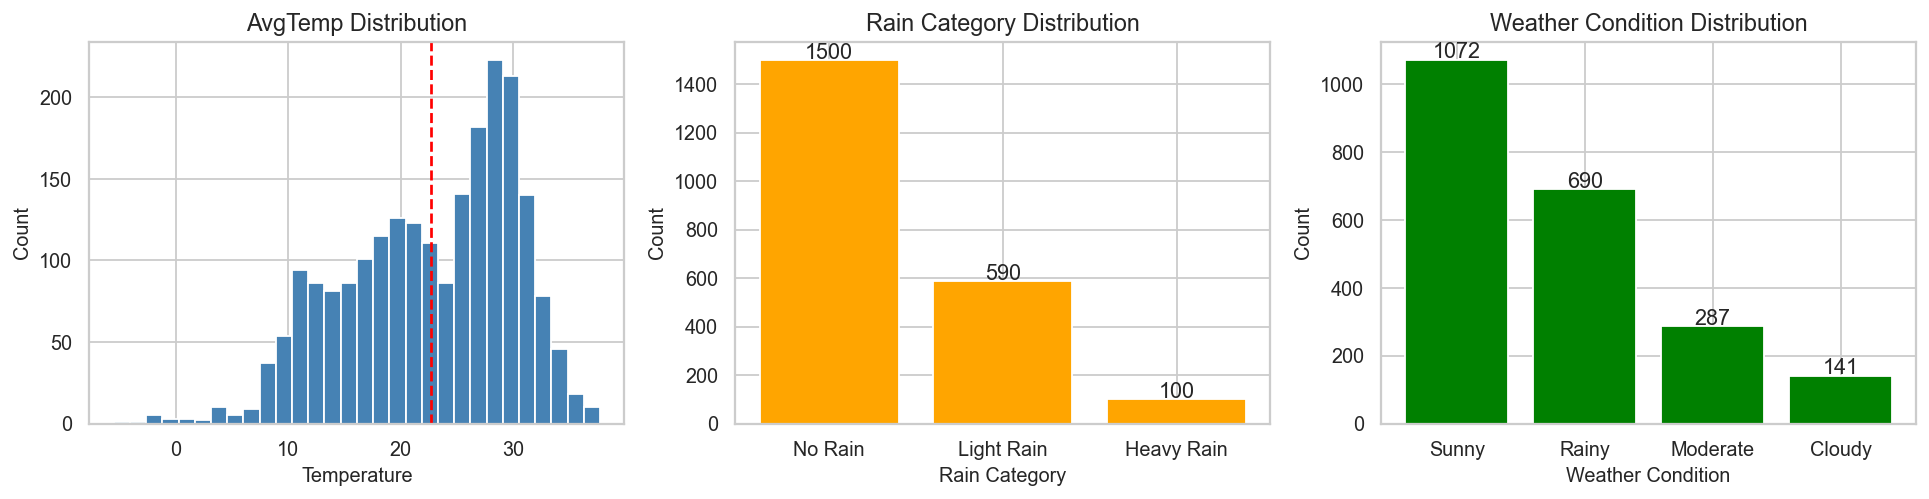

In [26]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(15,4))

# ---------------- AvgTemp ----------------
plt.subplot(1,3,1)

plt.hist(df['AvgTemp'], bins=30, color='steelblue')
plt.title('AvgTemp Distribution')
plt.xlabel('Temperature')
plt.ylabel('Count')

# Mean line
plt.axvline(df['AvgTemp'].mean(), color='red', linestyle='--')

# ---------------- RainCategory ----------------
plt.subplot(1,3,2)


rain_counts = df['RainCategory'].value_counts()

bars = plt.bar(rain_counts.index, rain_counts.values, color='orange')

# Show count on bars
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 5,
             int(y), ha='center')

plt.title('Rain Category Distribution')
plt.xlabel('Rain Category')
plt.ylabel('Count')

# ---------------- WeatherCondition ----------------
plt.subplot(1,3,3)

weather_counts = df['WeatherCondition'].value_counts()

bars = plt.bar(weather_counts.index, weather_counts.values, color='green')

# Show count on bars
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 5,
             int(y), ha='center')

plt.title('Weather Condition Distribution')
plt.xlabel('Weather Condition')
plt.ylabel('Count')

# Layout
plt.tight_layout()

# Save graph
plt.savefig('target_distribution.png')

# Show graph
plt.show()

### 2.2 Temperature Trends

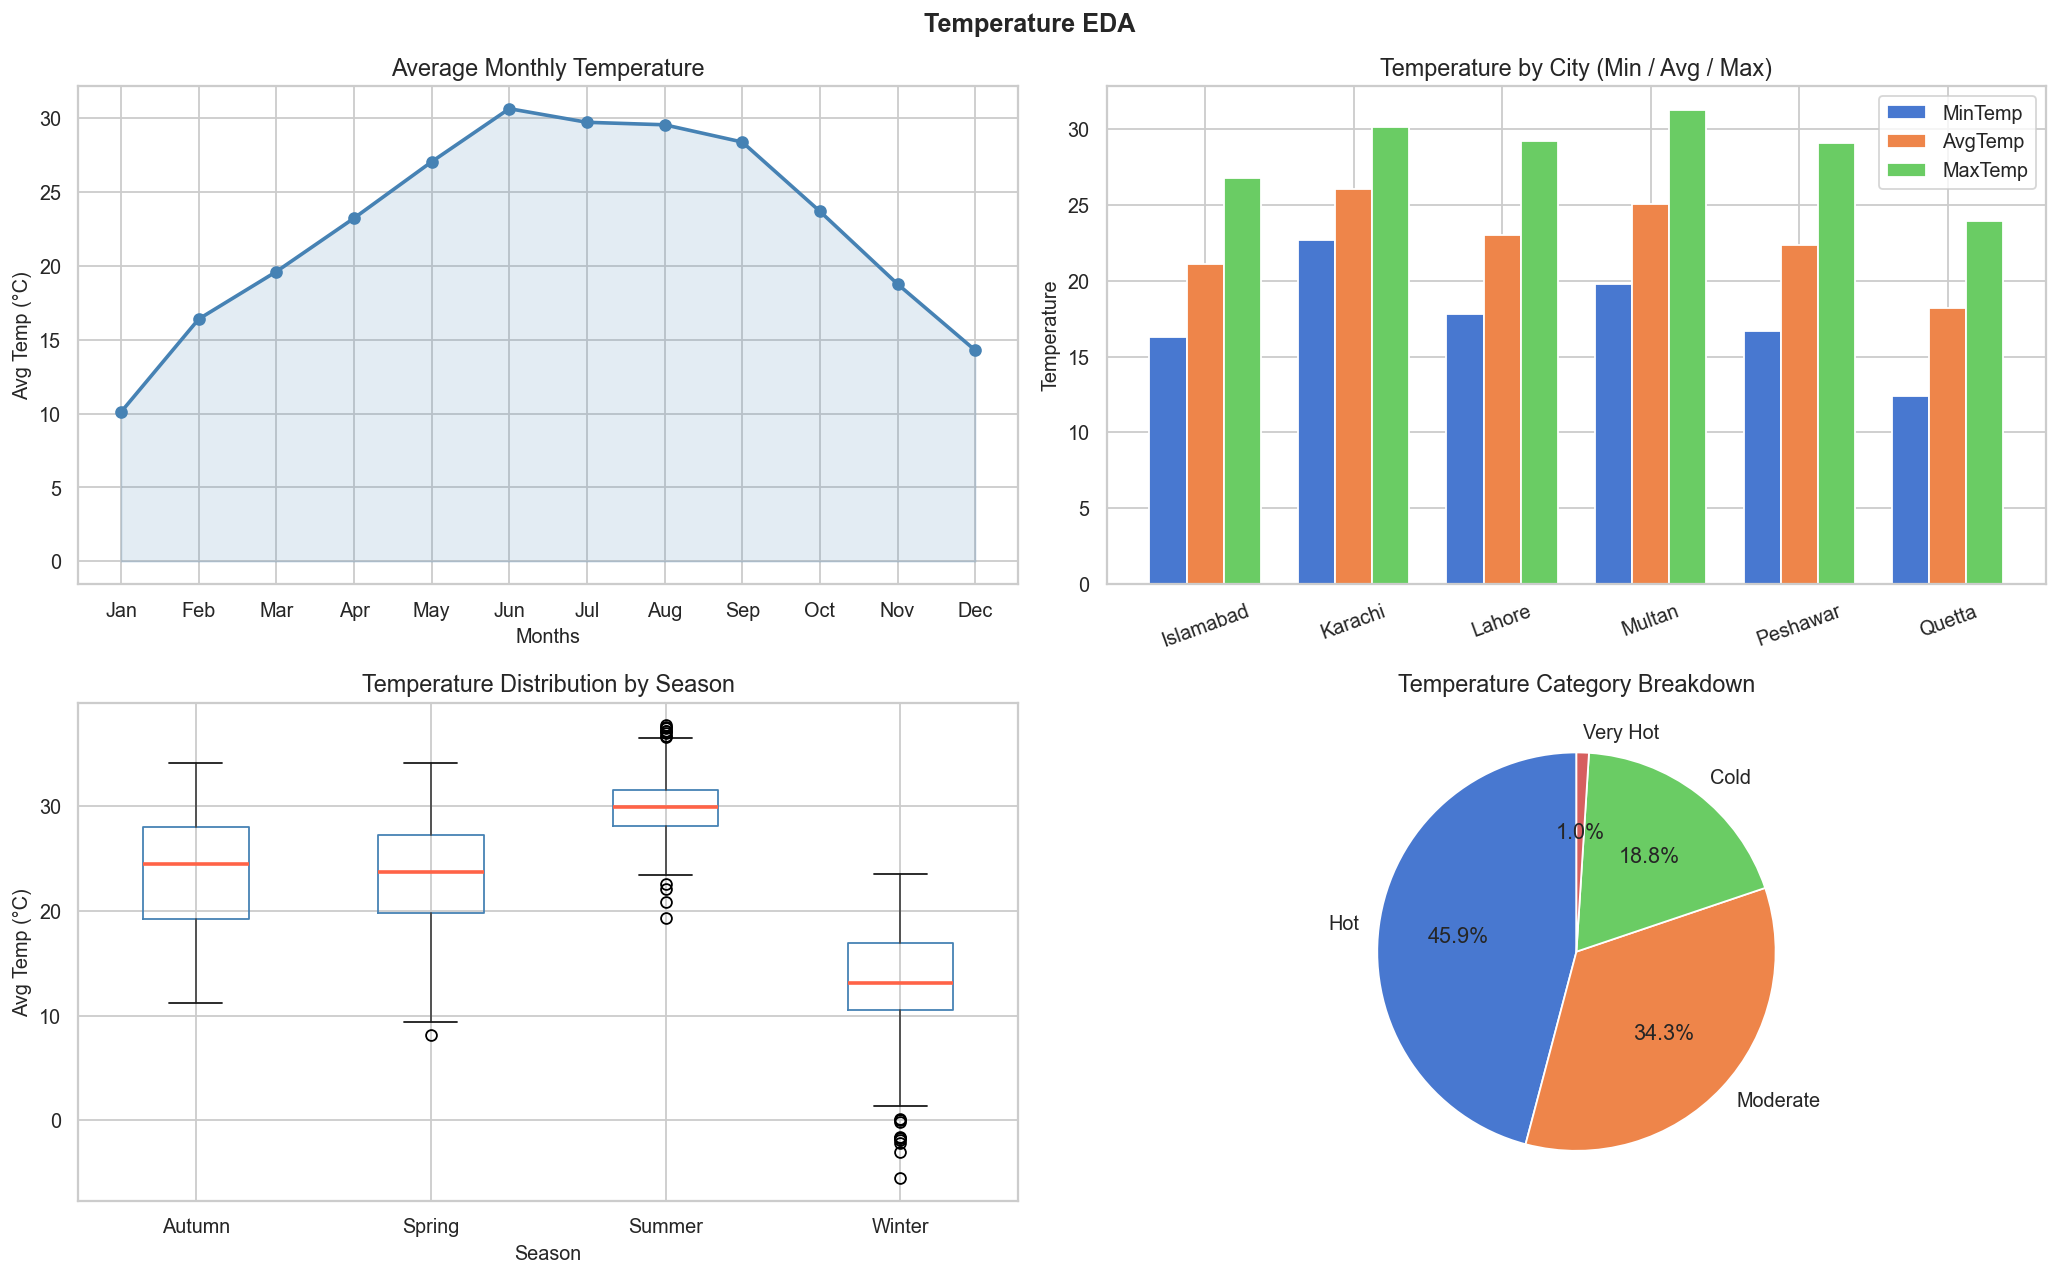

In [27]:
# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16,10))


# Monthly avg temperature
monthly = df.groupby('Month')['AvgTemp'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

axes[0,0].plot(monthly.index, monthly.values, marker='o', color='steelblue', linewidth=2)
axes[0,0].fill_between(monthly.index, monthly.values, alpha=0.15, color='steelblue')

axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels(month_names)
axes[0,0].set_title('Average Monthly Temperature')
axes[0,0].set_ylabel('Avg Temp (°C)')
axes[0,0].set_xlabel('Months')


# ---------------- Temperature by City ----------------
city_temp = df.groupby('City')[['MinTemp','AvgTemp','MaxTemp']].mean()

x = np.arange(len(city_temp))
w = 0.25

axes[0,1].bar(x-w, city_temp['MinTemp'], width=w, label='MinTemp')
axes[0,1].bar(x, city_temp['AvgTemp'], width=w, label='AvgTemp')
axes[0,1].bar(x+w, city_temp['MaxTemp'], width=w, label='MaxTemp')

axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(city_temp.index, rotation=20)

axes[0,1].set_title('Temperature by City (Min / Avg / Max)')
axes[0,1].set_ylabel('Temperature')
axes[0,1].legend()


# ---------------- Temperature by Season ----------------
df.boxplot(column='AvgTemp',
           by='Season',
           ax=axes[1,0],
          boxprops=dict(color='steelblue'), medianprops=dict(color='tomato', linewidth=2))

axes[1,0].set_title('Temperature Distribution by Season')
axes[1,0].set_xlabel('Season')
axes[1,0].set_ylabel('Avg Temp (°C)')


# ---------------- Temperature Category Pie Chart ----------------
temp_counts = df['TempCategory'].value_counts()

axes[1,1].pie(temp_counts.values,
              labels=temp_counts.index,
              autopct='%1.1f%%',
              startangle=90)

axes[1,1].set_title('Temperature Category Breakdown')


# Main title
plt.suptitle('Temperature EDA',  fontsize=14, fontweight='bold')

# Adjust layout
plt.tight_layout()

# Save graph
plt.savefig('temperature_eda.png')

# Show graph
plt.show()

### 2.3 Rainfall & Humidity Analysis

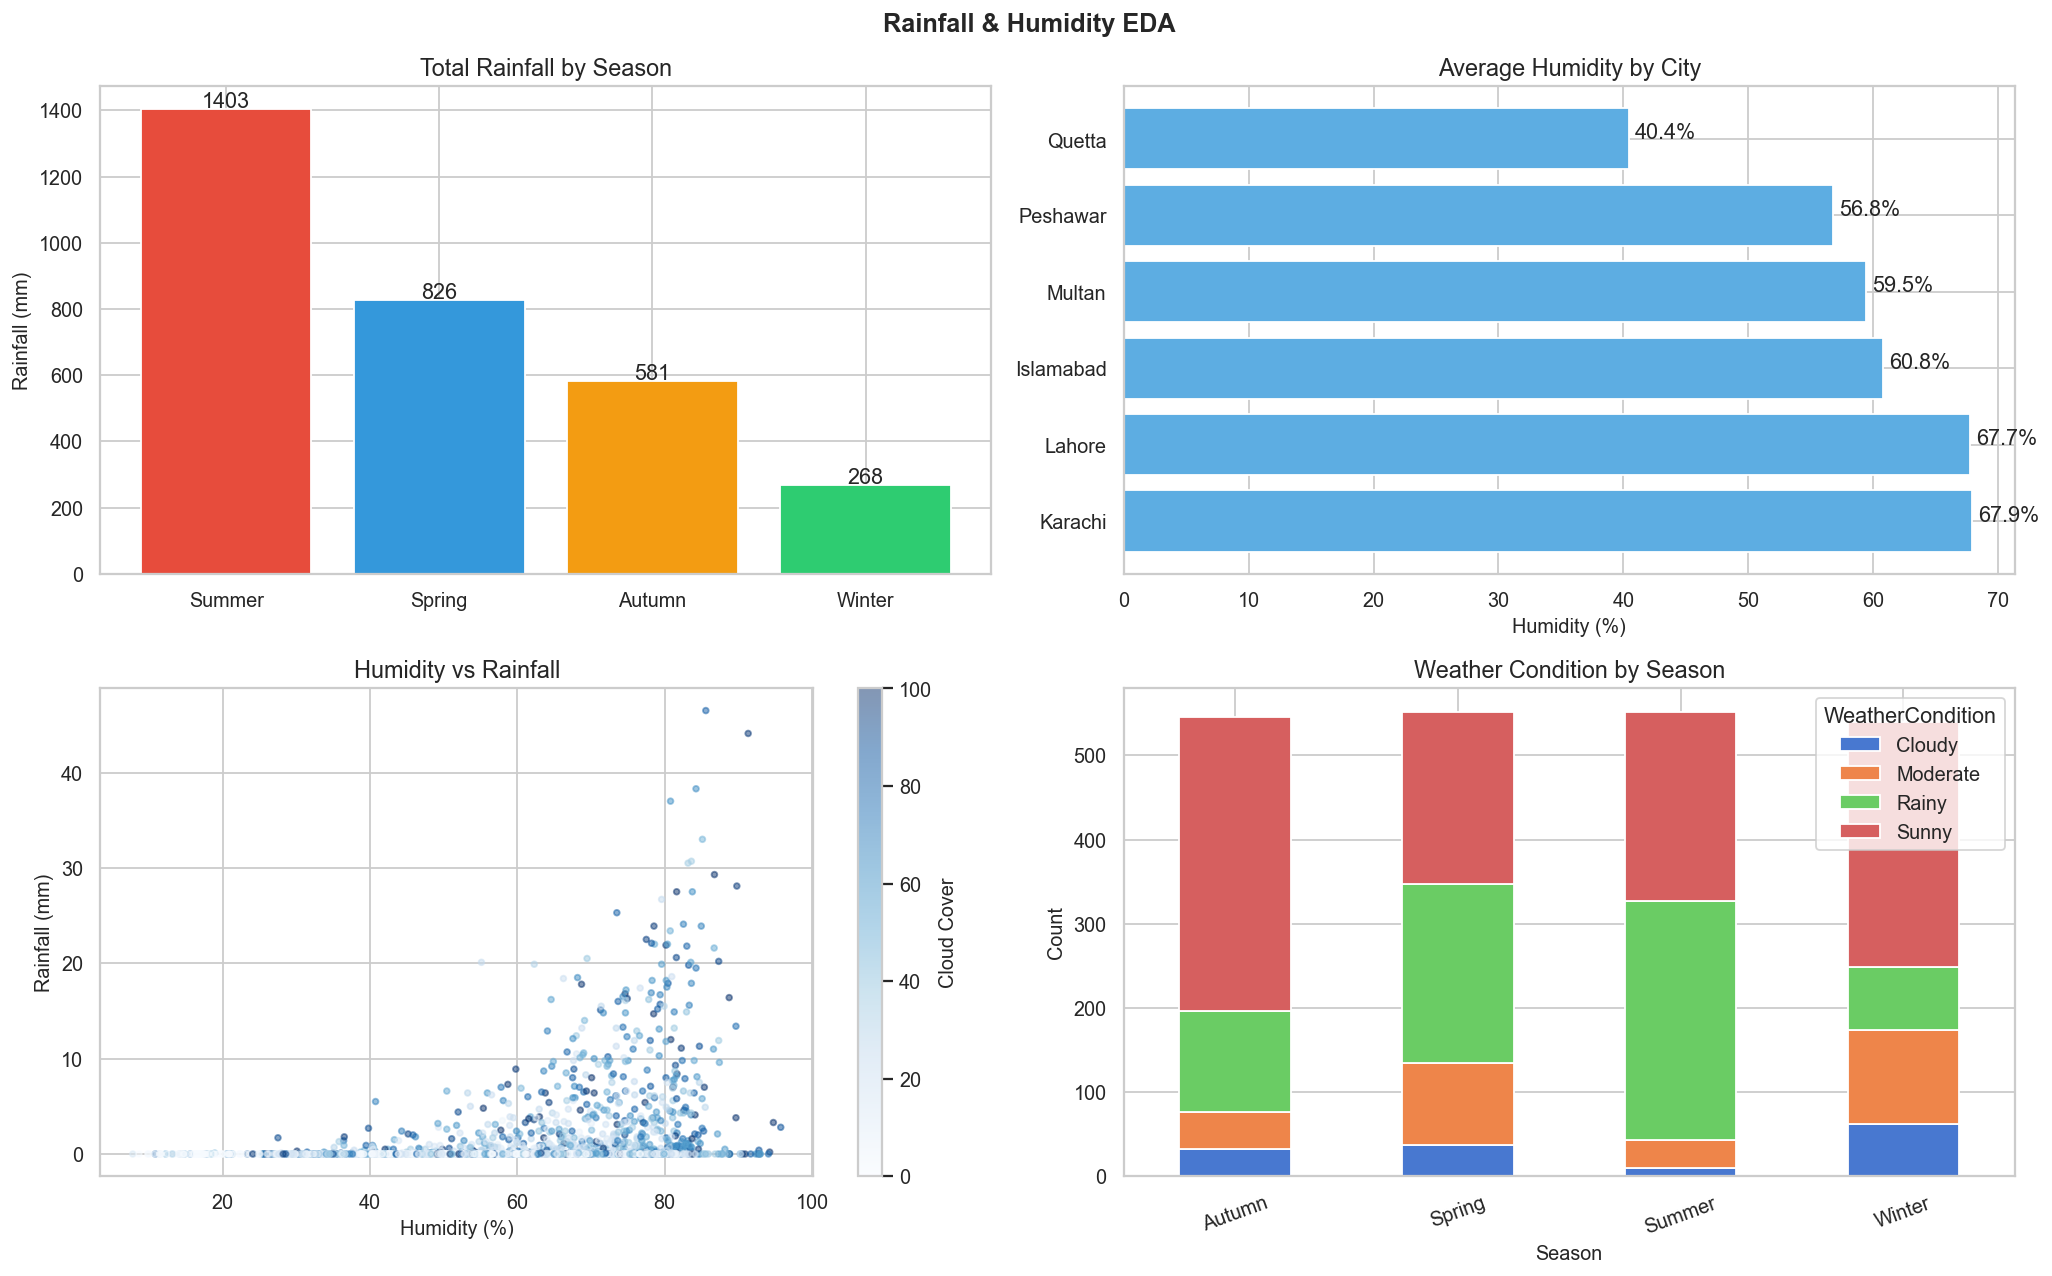

In [28]:
# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# ---------------- Rainfall by Season ----------------
season_rain = df.groupby('Season')['Rainfall'].sum().sort_values(ascending=False)

bars = axes[0,0].bar(season_rain.index,
                     season_rain.values,
                    color=['#e74c3c','#3498db','#f39c12','#2ecc71'], edgecolor='white')

# Show values on bars
for bar in bars:
    y = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   y + 5,
                   f'{y:.0f}',
                   ha='center')

axes[0,0].set_title('Total Rainfall by Season')
axes[0,0].set_ylabel('Rainfall (mm)')


# ---------------- Humidity by City ----------------
city_humidity = df.groupby('City')['Humidity'].mean().sort_values(ascending=False)

bars = axes[0,1].barh(city_humidity.index,
                      city_humidity.values,
                      color='#5dade2', edgecolor='white')

# Show values on bars
for i, val in enumerate(city_humidity.values):
    axes[0,1].text(val + 0.5,
                   i,
                   f'{val:.1f}%')

axes[0,1].set_title('Average Humidity by City')
axes[0,1].set_xlabel('Humidity (%)')

# ---------------- Humidity vs Rainfall ----------------
scatter = axes[1,0].scatter(df['Humidity'],
                            df['Rainfall'],
                            c=df['CloudCover'],
                            cmap='Blues',
                            alpha=0.5,
                            s=10)

plt.colorbar(scatter,
             ax=axes[1,0],
             label='Cloud Cover')

axes[1,0].set_title('Humidity vs Rainfall')
axes[1,0].set_xlabel('Humidity (%)')
axes[1,0].set_ylabel('Rainfall (mm)')



# ---------------- Weather Condition by Season ----------------
weather_season = df.groupby(
    ['Season','WeatherCondition']
).size().unstack()

weather_season.plot(kind='bar',
                    stacked=True,
                    ax=axes[1,1])

axes[1,1].set_title('Weather Condition by Season')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=20)


# Main title
plt.suptitle('Rainfall & Humidity EDA',  fontsize=14, fontweight='bold')

# Layout
plt.tight_layout()

# Save graph
plt.savefig('rainfall_humidity_eda.png')

# Show graph
plt.show()

### 2.4 Correlation Heatmap

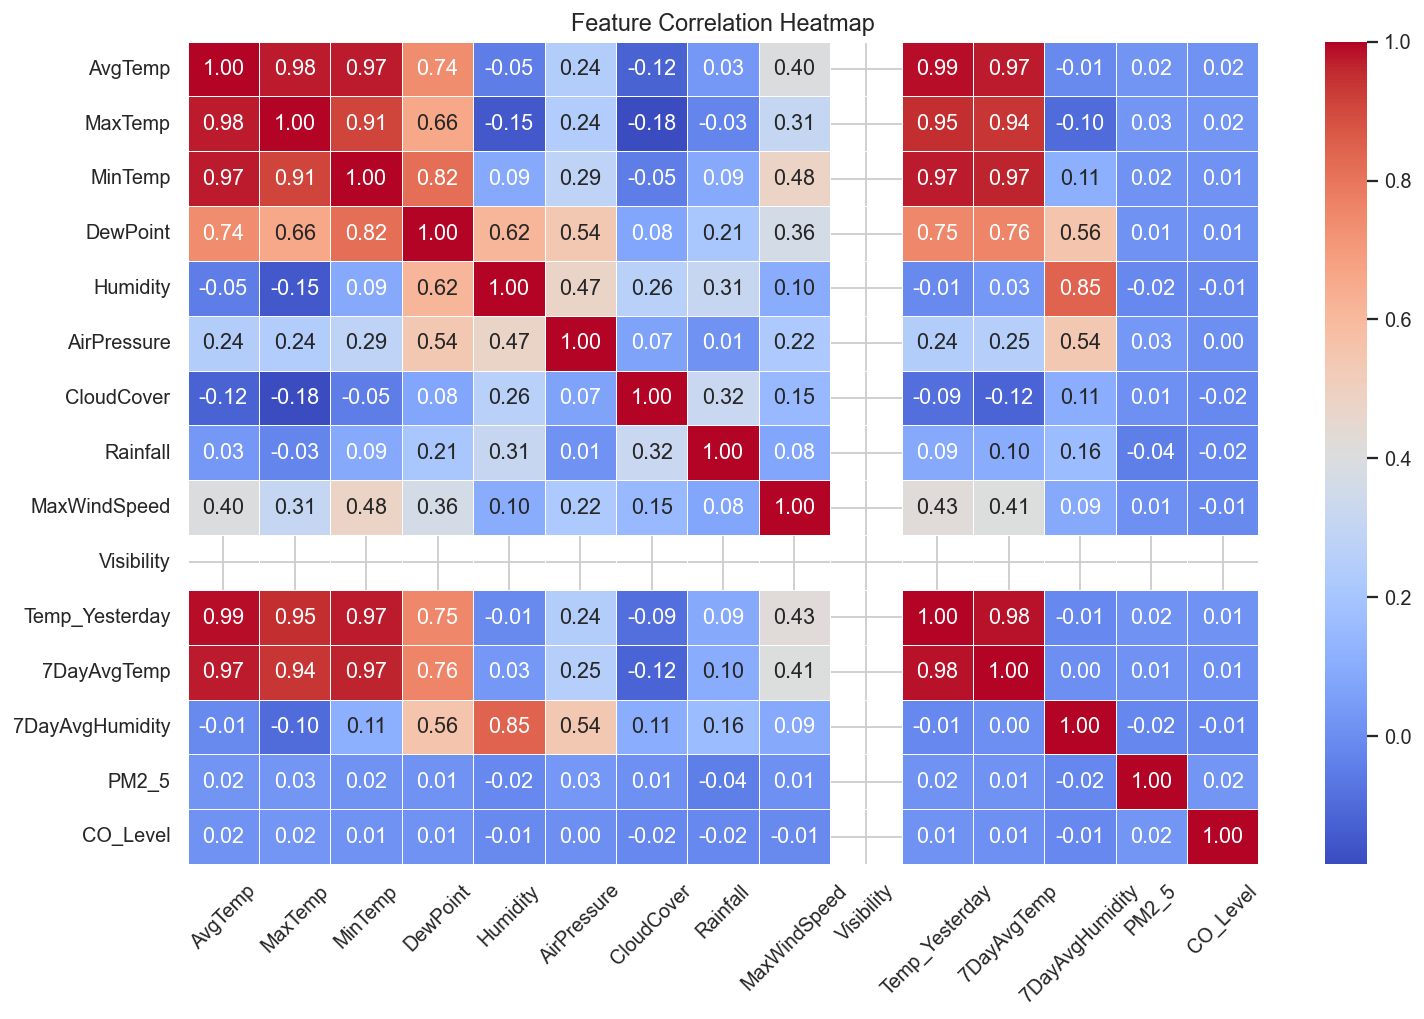

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select columns
cols = [
    'AvgTemp','MaxTemp','MinTemp','DewPoint',
    'Humidity','AirPressure','CloudCover','Rainfall',
    'MaxWindSpeed','Visibility','Temp_Yesterday',
    '7DayAvgTemp','7DayAvgHumidity','PM2_5','CO_Level'
]

# Correlation matrix
corr = df[cols].corr()

# Create figure
plt.figure(figsize=(12,8))

# Heatmap
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

# Title
plt.title('Feature Correlation Heatmap')

# Rotate labels
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Layout
plt.tight_layout()

# Save graph
plt.savefig('correlation_heatmap.png')

# Show graph
plt.show()

### 2.5 Feature Relationships with Targets

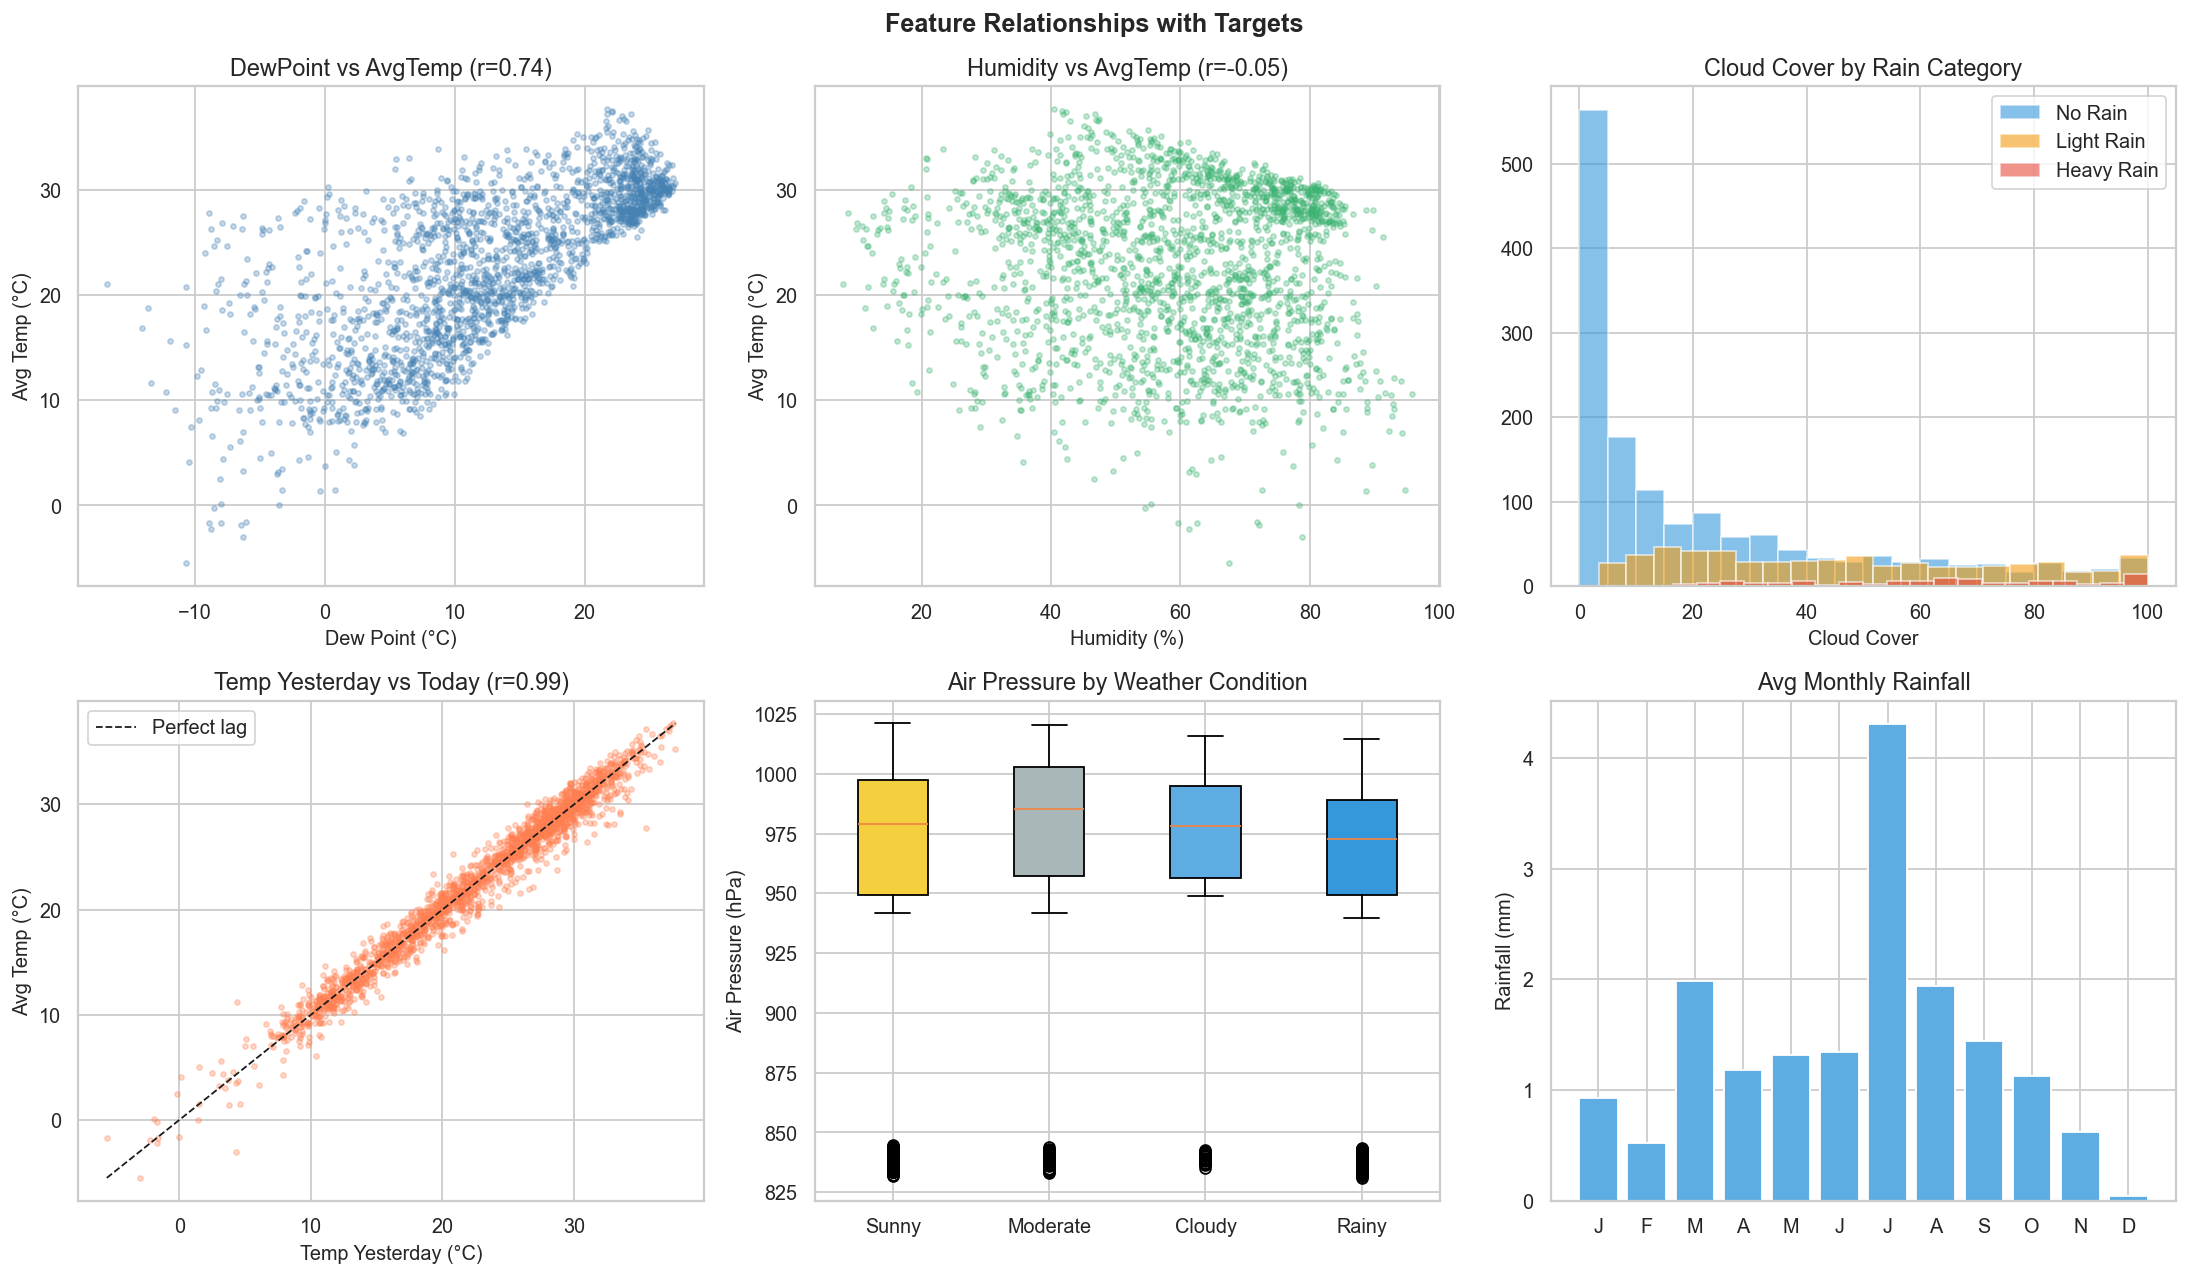

In [30]:
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(17,10))

# ---------------- DewPoint vs AvgTemp ----------------
corr1 = df[['DewPoint','AvgTemp']].corr().iloc[0,1]

axes[0,0].scatter(df['DewPoint'],
                  df['AvgTemp'],
                  alpha=0.3,
                  s=8,
                  color='steelblue')

axes[0,0].set_title(f'DewPoint vs AvgTemp (r={corr1:.2f})')
axes[0,0].set_xlabel('Dew Point (°C)')
axes[0,0].set_ylabel('Avg Temp (°C)')


# ---------------- Humidity vs AvgTemp ----------------
corr2 = df[['Humidity','AvgTemp']].corr().iloc[0,1]

axes[0,1].scatter(df['Humidity'],
                  df['AvgTemp'],
                  alpha=0.3,
                  s=8,
                  color='mediumseagreen')

axes[0,1].set_title(f'Humidity vs AvgTemp (r={corr2:.2f})')
axes[0,1].set_xlabel('Humidity (%)')
axes[0,1].set_ylabel('Avg Temp (°C)')


# ---------------- Cloud Cover by Rain Category ----------------
categories = ['No Rain', 'Light Rain', 'Heavy Rain']
colors = ['#3498db', '#f39c12', '#e74c3c']

for cat, color in zip(categories, colors):

    subset = df[df['RainCategory'] == cat]

    axes[0,2].hist(subset['CloudCover'],
                   bins=20,
                   alpha=0.6,
                   label=cat,
                   color=color,
                   edgecolor='white')

axes[0,2].set_title('Cloud Cover by Rain Category')
axes[0,2].set_xlabel('Cloud Cover')
axes[0,2].legend()


# ---------------- Temp Yesterday vs AvgTemp ----------------
corr3 = df[['Temp_Yesterday','AvgTemp']].corr().iloc[0,1]

axes[1,0].scatter(df['Temp_Yesterday'],
                  df['AvgTemp'],
                  alpha=0.3,
                  s=8,
                  color='coral')

# Perfect lag line
axes[1,0].plot(
    [df['Temp_Yesterday'].min(), df['Temp_Yesterday'].max()],
    [df['Temp_Yesterday'].min(), df['Temp_Yesterday'].max()],
    'k--',
    linewidth=1,
    label='Perfect lag'
)

axes[1,0].set_title(f'Temp Yesterday vs Today (r={corr3:.2f})')
axes[1,0].set_xlabel('Temp Yesterday (°C)')
axes[1,0].set_ylabel('Avg Temp (°C)')
axes[1,0].legend()


# ---------------- Air Pressure by Weather ----------------
order = ['Sunny', 'Moderate', 'Cloudy', 'Rainy']

data = [
    df[df['WeatherCondition'] == w]['AirPressure']
    for w in order
]

bp = axes[1,1].boxplot(data,
                       labels=order,
                       patch_artist=True)

box_colors = ['#f4d03f', '#aab7b8', '#5dade2', '#3498db']

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)

axes[1,1].set_title('Air Pressure by Weather Condition')
axes[1,1].set_ylabel('Air Pressure (hPa)')

# ---------------- Monthly Rainfall ----------------
monthly_rain = df.groupby('Month')['Rainfall'].mean()

axes[1,2].bar(monthly_rain.index,
              monthly_rain.values,
              color='#5dade2',
              edgecolor='white')

axes[1,2].set_xticks(range(1,13))
axes[1,2].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

axes[1,2].set_title('Avg Monthly Rainfall')
axes[1,2].set_ylabel('Rainfall (mm)')


# Main title
plt.suptitle('Feature Relationships with Targets',
             fontsize=14,
             fontweight='bold')

# Layout
plt.tight_layout()

# Save graph
plt.savefig('feature_relationships.png')

# Show graph
plt.show()

### 2.6 Time Series Overview

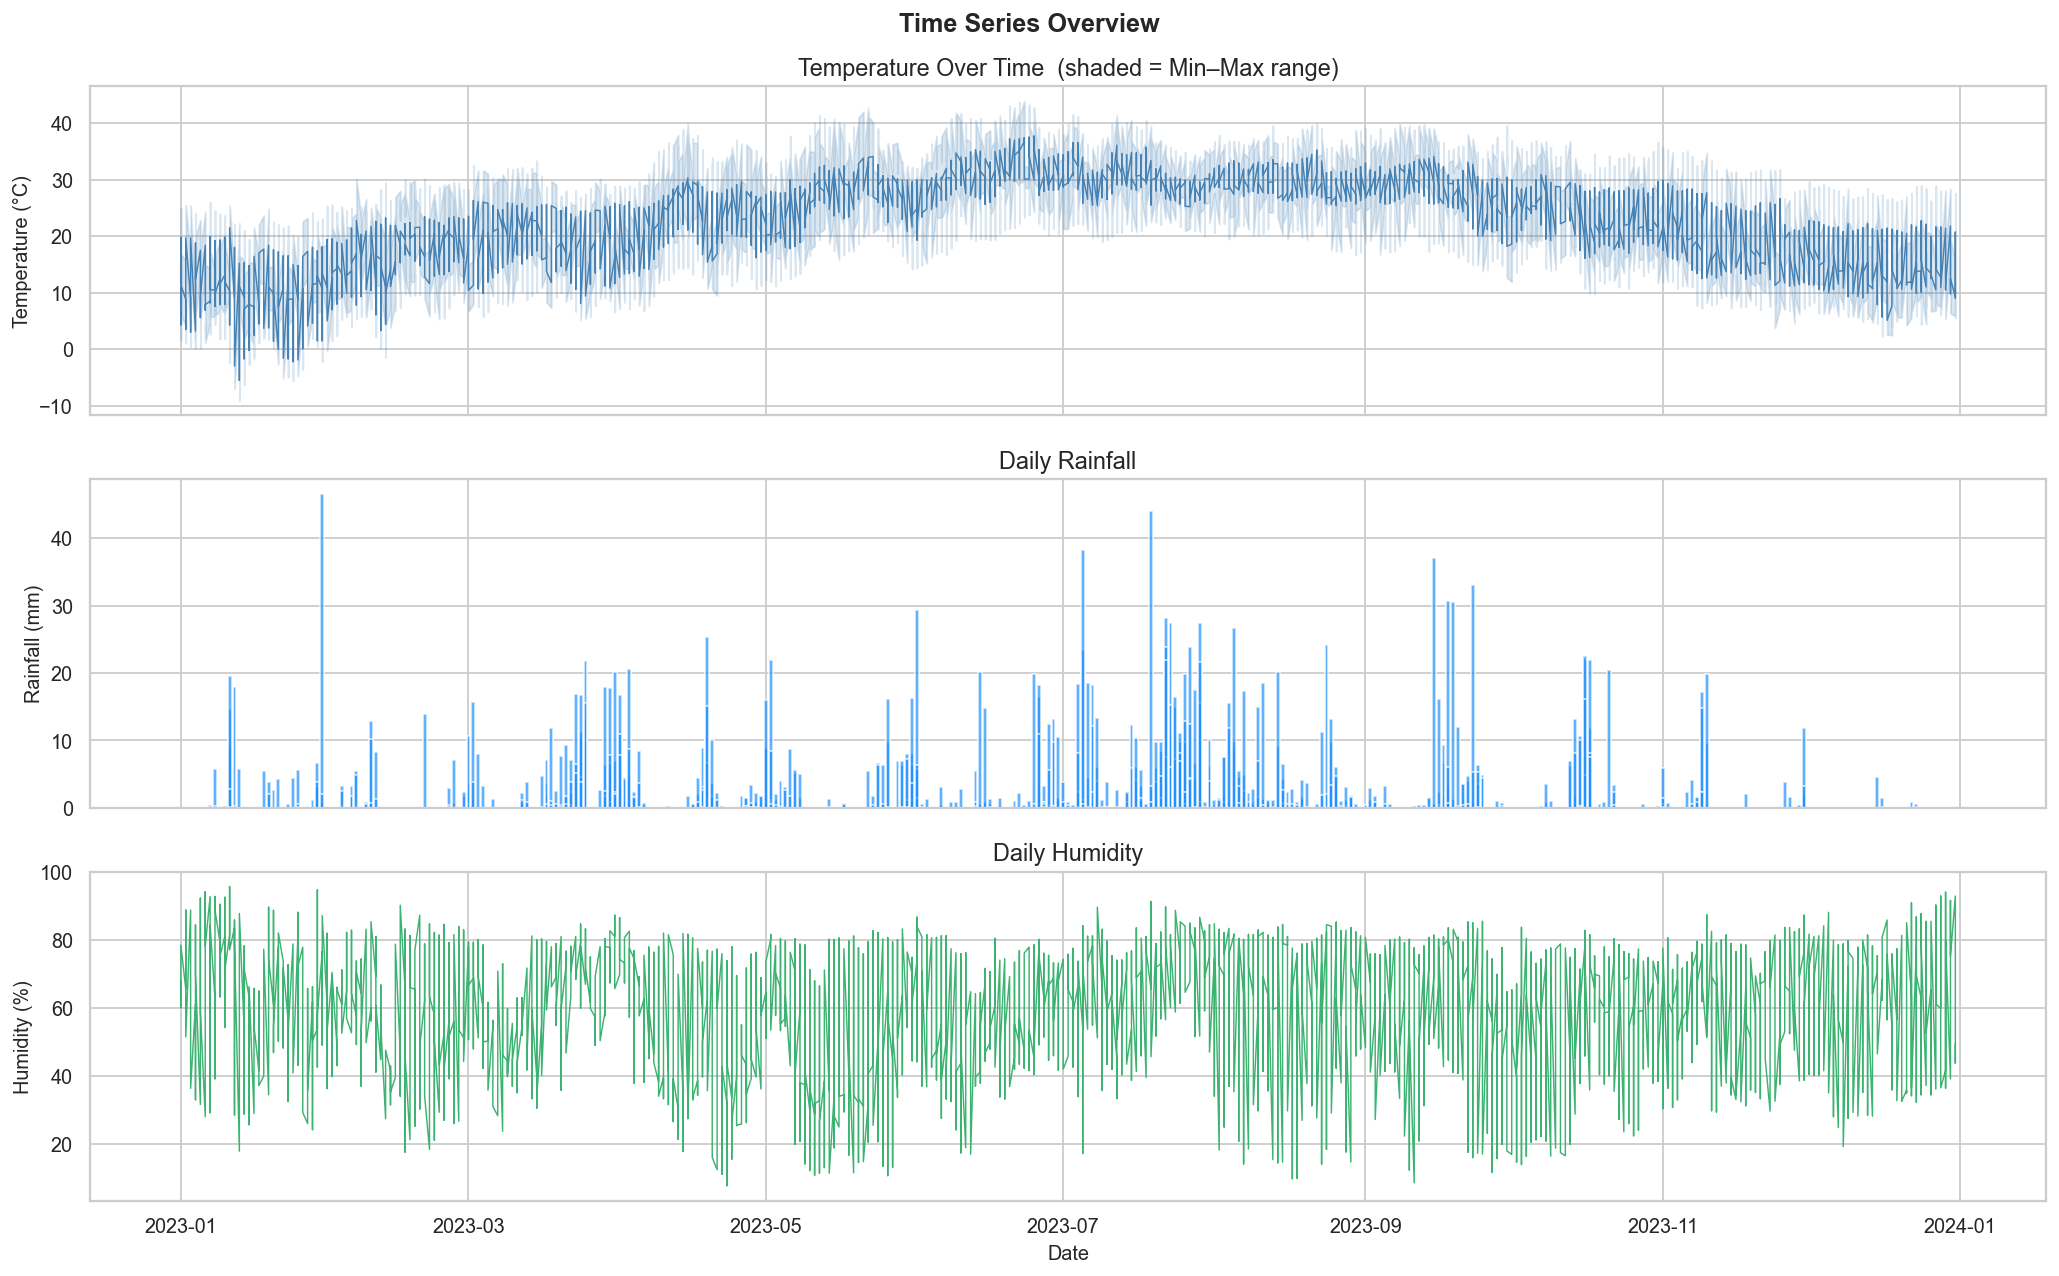

In [31]:
import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(16,10), sharex=True)

# ---------------- Temperature Over Time ----------------
axes[0].plot(df['Date'],
             df['AvgTemp'],
             color='steelblue',
             linewidth=0.8)

# Min-Max shaded area
axes[0].fill_between(df['Date'],
                     df['MinTemp'],
                     df['MaxTemp'],
                     color='steelblue',
                     alpha=0.2)

axes[0].set_title('Temperature Over Time  (shaded = Min–Max range)')
axes[0].set_ylabel('Temperature (°C)')


# ---------------- Rainfall Over Time ----------------
axes[1].bar(df['Date'],
            df['Rainfall'],
            color='dodgerblue',
            alpha=0.7)

axes[1].set_title('Daily Rainfall')
axes[1].set_ylabel('Rainfall (mm)')


# ---------------- Humidity Over Time ----------------
axes[2].plot(df['Date'],
             df['Humidity'],
             color='mediumseagreen',
             linewidth=0.8)

axes[2].set_title('Daily Humidity')
axes[2].set_ylabel('Humidity (%)')
axes[2].set_xlabel('Date')


# Main title
plt.suptitle('Time Series Overview', fontsize=14, fontweight='bold')

# Layout
plt.tight_layout()

# Save graph
plt.savefig('time_series_overview.png')

# Show graph
plt.show()

<a id='3'></a>
## 3. Feature Engineering

In [32]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ---------------- Fill Missing Values ----------------
cols = [
    'Temp_Yesterday',
    'Humidity_Yesterday',
    'Rainfall_Yesterday',
    '7DayAvgTemp',
    '7DayAvgHumidity',
    '7DayAvgRainfall'
]

for col in cols:
    df[col] = df[col].fillna(df[col].median())


# ---------------- Encode City ----------------
le_city = LabelEncoder()

df['City_enc'] = le_city.fit_transform(df['City'])

print("City Encoding:")
print(dict(zip(le_city.classes_,
               le_city.transform(le_city.classes_))))


# ---------------- Encode Season ----------------
df = pd.get_dummies(df,
                    columns=['Season'])


# ---------------- Month Encoding ----------------
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)

df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)


# ---------------- Rain Binary ----------------
df['Rain_Binary'] = (
    df['RainCategory'] != 'No Rain'
).astype(int)


# ---------------- Weather Condition Encoding ----------------
le_wc = LabelEncoder()

df['WC_Label'] = le_wc.fit_transform(
    df['WeatherCondition']
)

print("\nWeather Condition Encoding:")
print(dict(zip(le_wc.classes_,
               le_wc.transform(le_wc.classes_))))


# ---------------- Features ----------------
FEATURES = [
    'Temp_Yesterday',
    '7DayAvgTemp',
    'Humidity',
    'Humidity_Yesterday',
    '7DayAvgHumidity',
    'AirPressure',
    'DewPoint',
    'CloudCover',
    'MaxWindSpeed',
    'Rainfall_Yesterday',
    '7DayAvgRainfall',
    'Visibility',
    'Weekend',
    'City_enc',
    'Month_sin',
    'Month_cos',
    'Season_Autumn',
    'Season_Spring',
    'Season_Summer',
    'Season_Winter'
]

# ---------------- Final Check ----------------
print("\nTotal Features:", len(FEATURES))

print("Missing Values:",
      df[FEATURES].isnull().sum().sum())

City Encoding:
{'Islamabad': np.int64(0), 'Karachi': np.int64(1), 'Lahore': np.int64(2), 'Multan': np.int64(3), 'Peshawar': np.int64(4), 'Quetta': np.int64(5)}

Weather Condition Encoding:
{'Cloudy': np.int64(0), 'Moderate': np.int64(1), 'Rainy': np.int64(2), 'Sunny': np.int64(3)}

Total Features: 20
Missing Values: 0


In [33]:
# ---------------- Train-Test Split ----------------

split = int(len(df) * 0.8)
train_df = df[:split]
test_df = df[split:]


print(f'Training : {len(train_df)} rows  ({train_df["Date"].min().date()} → {train_df["Date"].max().date()})')
print(f'Test     : {len(test_df)} rows  ({test_df["Date"].min().date()} → {test_df["Date"].max().date()})')

Training : 1752 rows  (2023-01-01 → 2023-10-19)
Test     : 438 rows  (2023-10-20 → 2023-12-31)


<a id='4'></a>
## 🌡️ Task 1 — Temperature Prediction (Regression)
**Target:** `AvgTemp`

In [34]:
# ==========================================
# Features and Target
# ==========================================

X_train_r = train_df[FEATURES]
y_train_r = train_df['AvgTemp']
X_test_r  = test_df[FEATURES]
y_test_r  = test_df['AvgTemp']

# ==========================================
# Create Models
# ==========================================

lr_reg  = LinearRegression()

dt_reg = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

rf_reg  = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

gbr_reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)

xgb_reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

# ==========================================
# Train Models
# ==========================================

lr_reg.fit(X_train_r, y_train_r)
dt_reg.fit(X_train_r, y_train_r)
rf_reg.fit(X_train_r, y_train_r)
gbr_reg.fit(X_train_r, y_train_r)
xgb_reg.fit(X_train_r, y_train_r)

print('All regression models trained!')

All regression models trained!


In [35]:
def reg_report(name, model, X_tr, y_tr, X_te, y_te):
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)
    return {
        'Model': name,
        'Train MAE': round(mean_absolute_error(y_tr, tr_pred), 3),
        'Train RMSE': round(np.sqrt(mean_squared_error(y_tr, tr_pred)), 3),
        'Train R²': round(r2_score(y_tr, tr_pred), 4),
        'Test MAE': round(mean_absolute_error(y_te, te_pred), 3),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_te, te_pred)), 3),
        'Test R²': round(r2_score(y_te, te_pred), 4),
        '_test_pred': te_pred
    }

results_r = []
preds_r   = {}
for name, model in [('Linear Regression', lr_reg),
                    ('Decision Tree',  dt_reg),
                     ('Random Forest',  rf_reg),
                     ('Gradient Boosting', gbr_reg),
                     ('XGBoost',  xgb_reg)]:
    r = reg_report(name, model, X_train_r, y_train_r, X_test_r, y_test_r)
    preds_r[name] = r.pop('_test_pred')
    results_r.append(r)

results_r_df = pd.DataFrame(results_r).set_index('Model')
print('=== Task 1: Temperature — Train vs Test Scores ===')
results_r_df

=== Task 1: Temperature — Train vs Test Scores ===


,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²
Model,,,,,,
Linear Regression,0.659,0.961,0.9835,0.616,0.776,0.9756
Decision Tree,0.343,0.535,0.9949,1.374,2.421,0.7629
Random Forest,0.410,0.538,0.9948,1.378,2.324,0.7815
Gradient Boosting,0.302,0.389,0.9973,0.965,1.558,0.9018
XGBoost,0.137,0.179,0.9994,0.974,1.627,0.8930


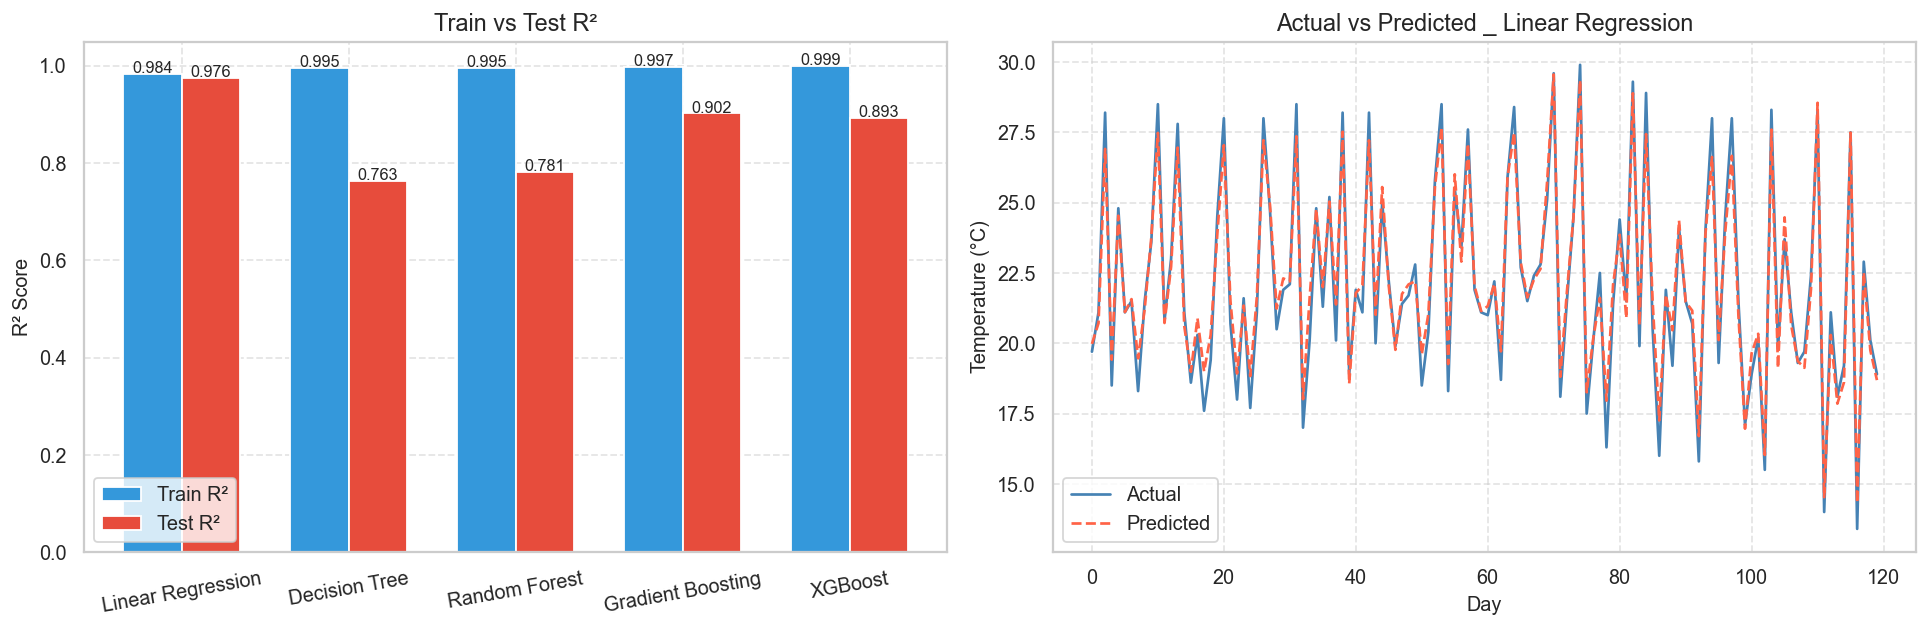

In [36]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# ---------------- Train vs Test R² ----------------
models = results_r_df.index

train_r2 = results_r_df['Train R²']

test_r2 = results_r_df['Test R²']

x = np.arange(len(models))

w = 0.35

# Bars
axes[0].bar(x - w/2,
            train_r2,
            width=w,
            color='#3498db',
            label='Train R²')

axes[0].bar(x + w/2,
            test_r2,
            width=w,
            color='#e74c3c',
            label='Test R²')

# Labels
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=10)

axes[0].set_ylabel('R² Score')

axes[0].set_title('Train vs Test R²')

axes[0].legend()

# Show values on bars
for i in range(len(models)):

    axes[0].text(x[i] - w/2,
                 train_r2[i] + 0.002,
                 f'{train_r2[i]:.3f}',
                 ha='center',
                 fontsize=9)

    axes[0].text(x[i] + w/2,
                 test_r2[i] + 0.002,
                 f'{test_r2[i]:.3f}',
                 ha='center',
                 fontsize=9)


# ---------------- Actual vs Predicted ----------------
best_preds = preds_r['Linear Regression']

axes[1].plot(y_test_r.values[:120],
             color='steelblue',
             linewidth=1.5,
             label='Actual')

axes[1].plot(best_preds[:120],
             color='tomato',
             linestyle='--',
             linewidth=1.5,
             label='Predicted')

axes[1].set_title('Actual vs Predicted _ Linear Regression')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Temperature (°C)')

axes[1].legend()


# Same grid style
for ax in axes.flat:
    ax.grid(True, linestyle='--', alpha=0.5)


# Layout
plt.tight_layout()

# Save graph
plt.savefig('model_results.png')

# Show graph
plt.show()

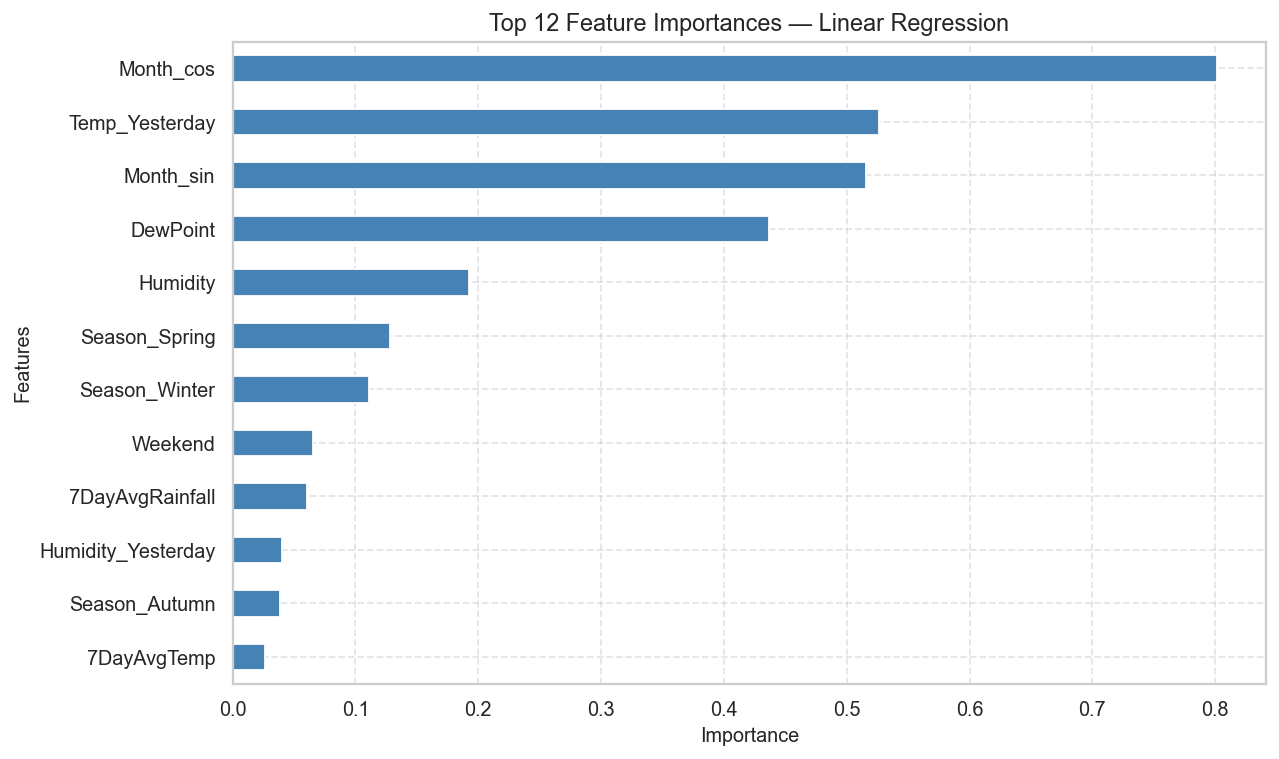

In [37]:
# Feature importance
feat_imp = pd.Series(
    abs(lr_reg.coef_),
    index=FEATURES
).sort_values(ascending=False)

# Create figure
plt.figure(figsize=(10,6))

# Bar graph
feat_imp.head(12).plot(kind='barh',
                       color='steelblue',
                       edgecolor='white')

# Highest at top
plt.gca().invert_yaxis()

# Labels
plt.title('Top 12 Feature Importances — Linear Regression')
plt.xlabel('Importance')
plt.ylabel('Features')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Layout
plt.tight_layout()

# Save graph
plt.savefig('feature_importance.png')

# Show graph
plt.show()

**💡 Key Insight:** `Temp_Yesterday` and `7DayAvgTemp` dominate feature importance (r=0.987 with AvgTemp). Random Forest overfits (Train R²=0.997, Test R²=0.805), while Linear Regression generalises best despite lower training score.

<a id='5'></a>
## 🌧️ Task 2 — Rain Classification (Binary)
**Target:** No Rain (0) vs Rain (1) | **Metrics:** Accuracy, F1-score

In [38]:
# ---------------- Class Distribution ----------------
print("Rain Class Distribution:\n")

print(
    train_df['Rain_Binary']
    .value_counts()
    .rename({
        0: 'No Rain (0)',
        1: 'Rain (1)'
    })
)

# ---------------- Imbalance Ratio ----------------
no_rain = (train_df['Rain_Binary'] == 0).sum()

rain = (train_df['Rain_Binary'] == 1).sum()

print(f"\nClass Imbalance Ratio: {no_rain/rain:.1f}:1")


# ---------------- Features and Target ----------------
X_train_c = train_df[FEATURES]

y_train_c = train_df['Rain_Binary']

X_test_c = test_df[FEATURES]

y_test_c = test_df['Rain_Binary']

Rain Class Distribution:

Rain_Binary
No Rain (0)    1111
Rain (1)        641
Name: count, dtype: int64

Class Imbalance Ratio: 1.7:1


In [39]:
# Train classifiers
log_clf  = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rf_clf   = RandomForestClassifier(n_estimators=200, max_depth=15,
                                   class_weight='balanced', random_state=42, n_jobs=-1)
gbc_clf  = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                       max_depth=5, random_state=42)

log_clf.fit(X_train_c, y_train_c)
rf_clf.fit(X_train_c, y_train_c)
gbc_clf.fit(X_train_c, y_train_c)

print('✅ All rain classifiers trained!')

✅ All rain classifiers trained!


In [40]:
# Add this after your existing classifier definitions
from xgboost import XGBClassifier

# Calculate scale_pos_weight = No Rain count / Rain count
no_rain_count = (y_train_c == 0).sum()
rain_count = (y_train_c == 1).sum()
spw = no_rain_count / rain_count

xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=spw,   # handles class imbalance
    random_state=42,
    eval_metric='logloss'
)

xgb_clf.fit(X_train_c, y_train_c)
print(f'XGBoost trained! scale_pos_weight = {spw:.2f}')

XGBoost trained! scale_pos_weight = 1.73


In [41]:
from sklearn.metrics import roc_auc_score

def clf_report(name, model, X_tr, y_tr, X_te, y_te, average='binary'):
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)
    
    # ROC-AUC (only for binary classification)
    if average == 'binary':
        tr_auc = round(roc_auc_score(y_tr, model.predict_proba(X_tr)[:,1]), 4)
        te_auc = round(roc_auc_score(y_te, model.predict_proba(X_te)[:,1]), 4)
    else:
        tr_auc = '-'
        te_auc = '-'
    
    return {
        'Model': name,
        'Train Accuracy': round(accuracy_score(y_tr, tr_pred), 4),
        'Train F1':       round(f1_score(y_tr, tr_pred, average=average), 4),
        'Train AUC':      tr_auc,
        'Test Accuracy':  round(accuracy_score(y_te, te_pred), 4),
        'Test F1':        round(f1_score(y_te, te_pred, average=average), 4),
        'Test AUC':       te_auc,
        '_te_pred':       te_pred
    }
results_c = []
preds_c   = {}
for name, model in [('Logistic Regression', log_clf),
                     ('Random Forest',       rf_clf),
                     ('Gradient Boosting',   gbc_clf),
                     ('XGBoost',             xgb_clf)]:
    r = clf_report(name, model, X_train_c, y_train_c, X_test_c, y_test_c)
    preds_c[name] = r.pop('_te_pred')
    results_c.append(r)

results_c_df = pd.DataFrame(results_c).set_index('Model')
print('=== Task 2: Rain Classification — Train vs Test Scores ===')
results_c_df

=== Task 2: Rain Classification — Train vs Test Scores ===


,Train Accuracy,Train F1,Train AUC,Test Accuracy,Test F1,Test AUC
Model,,,,,,
Logistic Regression,0.8288,0.7817,0.9112,0.8311,0.4219,0.8363
Random Forest,1.0000,1.0000,1.0000,0.9247,0.6118,0.9214
Gradient Boosting,0.9983,0.9977,1.0000,0.9018,0.5275,0.9229
XGBoost,0.9732,0.9645,0.9978,0.9087,0.6000,0.9428


=== Classification Report: Random Forest ===
              precision    recall  f1-score   support

     No Rain       0.94      0.97      0.96       389
        Rain       0.72      0.53      0.61        49

    accuracy                           0.92       438
   macro avg       0.83      0.75      0.79       438
weighted avg       0.92      0.92      0.92       438



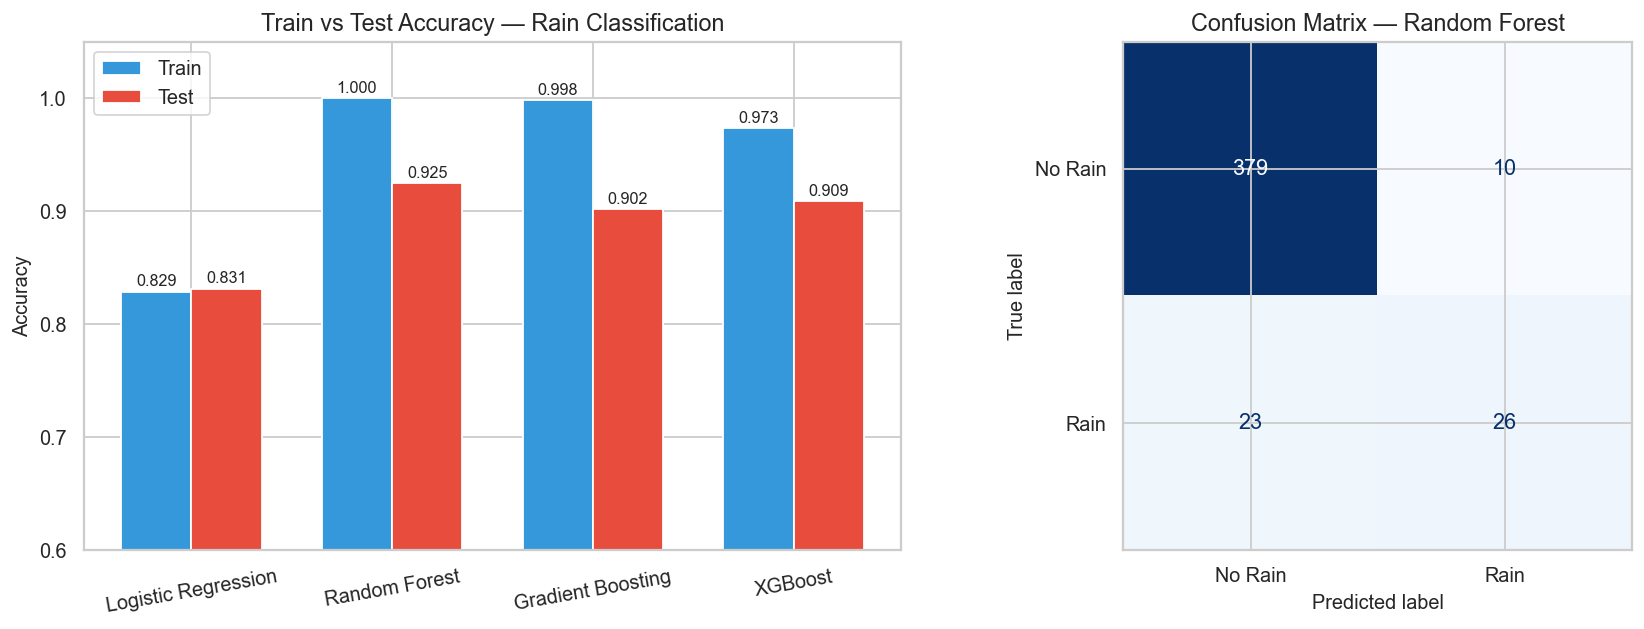

In [42]:
# Detailed report + confusion matrix for best model
best_c_preds = preds_c['Random Forest']
print('=== Classification Report: Random Forest ===')
print(classification_report(y_test_c, best_c_preds, target_names=['No Rain','Rain']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train vs Test Accuracy bar
x_pos = np.arange(len(results_c_df))
w = 0.35
tr_acc = results_c_df['Train Accuracy'].values
te_acc = results_c_df['Test Accuracy'].values
axes[0].bar(x_pos-w/2, tr_acc, width=w, label='Train', color='#3498db', edgecolor='white')
axes[0].bar(x_pos+w/2, te_acc, width=w, label='Test',  color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results_c_df.index, rotation=10)
axes[0].set_ylim(0.6, 1.05)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy — Rain Classification')
axes[0].legend()
for i,(tr,te) in enumerate(zip(tr_acc,te_acc)):
    axes[0].text(i-w/2, tr+0.005, f'{tr:.3f}', ha='center', fontsize=9)
    axes[0].text(i+w/2, te+0.005, f'{te:.3f}', ha='center', fontsize=9)

# Confusion Matrix
cm = confusion_matrix(y_test_c, best_c_preds)
ConfusionMatrixDisplay(cm, display_labels=['No Rain','Rain']).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix — Random Forest')

plt.tight_layout()
plt.savefig('task2_rain_results.png', bbox_inches='tight')
plt.show()

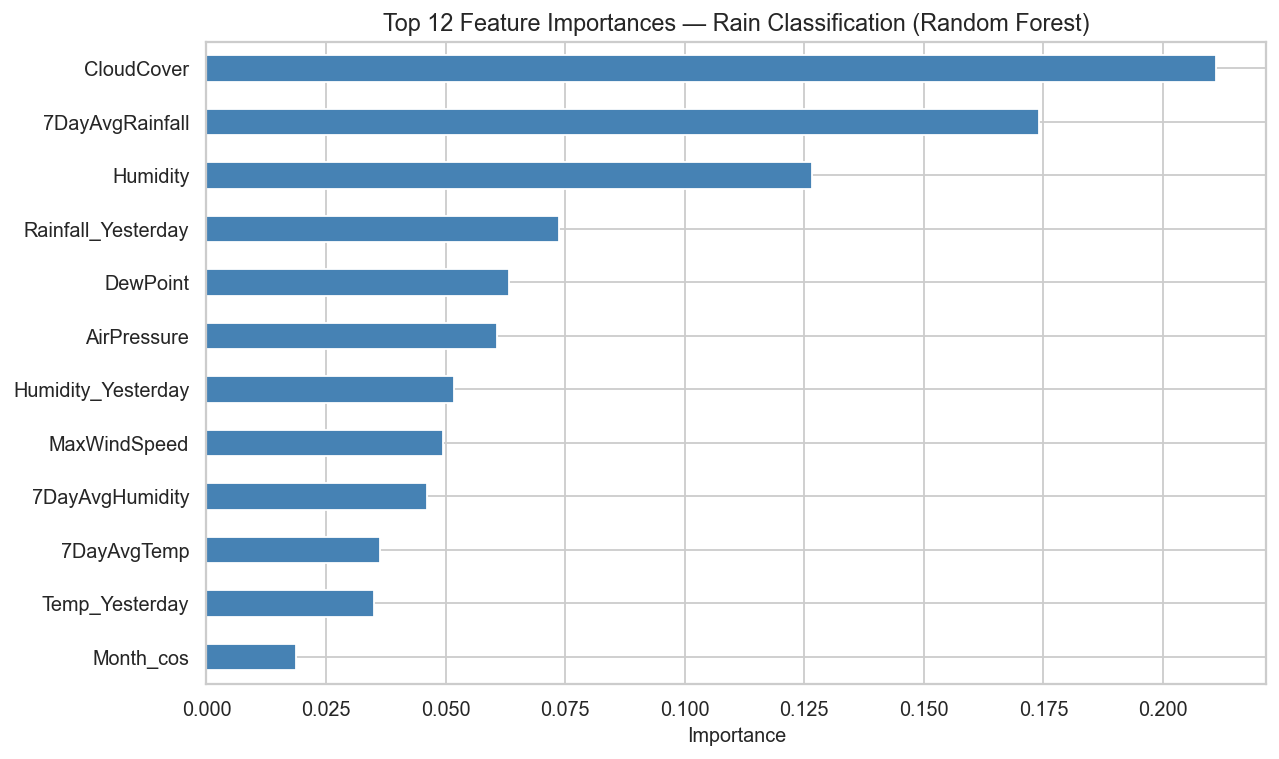

In [43]:
# Feature Importance — Rain Classification
feat_imp_c = pd.Series(rf_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp_c.head(12).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 12 Feature Importances — Rain Classification (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('task2_rain_feature_importance.png', bbox_inches='tight')
plt.show()

**💡 Key Insight:** Random Forest performed best for rain classification based on highest Test Accuracy and F1-score.

<a id='6'></a>
## ⛅ Task 3 — Weather Condition Prediction (Multi-class)
**Target:** Sunny / Rainy / Moderate / Cloudy | **Metrics:** Accuracy, Weighted F1

In [44]:
print('WeatherCondition class distribution (train):')
print(train_df['WeatherCondition'].value_counts())
print('\nEncoded labels:', dict(zip(le_wc.classes_, le_wc.transform(le_wc.classes_))))

X_train_m = train_df[FEATURES]
y_train_m = train_df['WC_Label']
X_test_m  = test_df[FEATURES]
y_test_m  = test_df['WC_Label']

WeatherCondition class distribution (train):
WeatherCondition
Sunny       801
Rainy       641
Moderate    211
Cloudy       99
Name: count, dtype: int64

Encoded labels: {'Cloudy': np.int64(0), 'Moderate': np.int64(1), 'Rainy': np.int64(2), 'Sunny': np.int64(3)}


In [45]:
log_mc  = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rf_mc   = RandomForestClassifier(n_estimators=200, max_depth=15,
                                  class_weight='balanced', random_state=42, n_jobs=-1)
gbc_mc  = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                      max_depth=5, random_state=42)

log_mc.fit(X_train_m, y_train_m)
rf_mc.fit(X_train_m, y_train_m)
gbc_mc.fit(X_train_m, y_train_m)
print('✅ All multi-class models trained!')

✅ All multi-class models trained!


In [46]:
results_m = []
preds_m   = {}
for name, model in [('Logistic Regression', log_mc),
                     ('Random Forest',       rf_mc),
                     ('Gradient Boosting',   gbc_mc)]:
    r = clf_report(name, model, X_train_m, y_train_m, X_test_m, y_test_m, average='weighted')
    preds_m[name] = r.pop('_te_pred')
    r['Train F1'] = round(r['Train F1'], 4)   # weighted F1
    r['Test F1']  = round(r['Test F1'],  4)
    results_m.append(r)

results_m_df = pd.DataFrame(results_m).set_index('Model')
print(results_m_df)
print('=== Task 3: Weather Condition — Train vs Test Scores ===')
results_m_df

                     Train Accuracy  Train F1 Train AUC  Test Accuracy  \
Model                                                                    
Logistic Regression          0.7871    0.7897         -         0.8311   
Random Forest                1.0000    1.0000         -         0.8790   
Gradient Boosting            1.0000    1.0000         -         0.9087   

                     Test F1 Test AUC  
Model                                  
Logistic Regression   0.8303        -  
Random Forest         0.8804        -  
Gradient Boosting     0.9070        -  
=== Task 3: Weather Condition — Train vs Test Scores ===


,Train Accuracy,Train F1,Train AUC,Test Accuracy,Test F1,Test AUC
Model,,,,,,
Logistic Regression,0.7871,0.7897,-,0.8311,0.8303,-
Random Forest,1.0000,1.0000,-,0.8790,0.8804,-
Gradient Boosting,1.0000,1.0000,-,0.9087,0.9070,-


=== Classification Report: Gradient Boosting ===
              precision    recall  f1-score   support

      Cloudy       0.93      0.93      0.93        42
    Moderate       0.91      0.92      0.92        76
       Rainy       0.60      0.55      0.57        49
       Sunny       0.96      0.97      0.96       271

    accuracy                           0.91       438
   macro avg       0.85      0.84      0.84       438
weighted avg       0.91      0.91      0.91       438



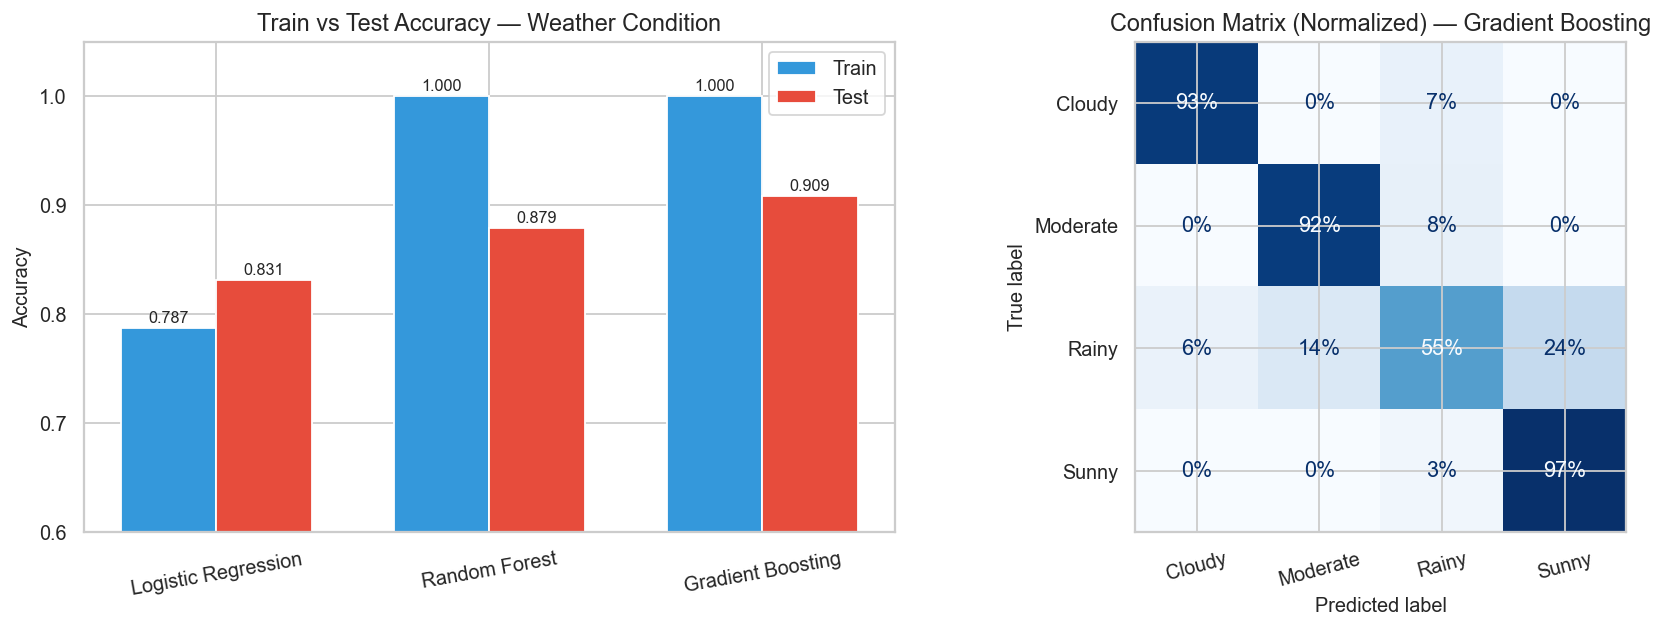

In [47]:
best_m_preds = preds_m['Gradient Boosting']
print('=== Classification Report: Gradient Boosting ===')
print(classification_report(y_test_m, best_m_preds, target_names=le_wc.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train vs Test Accuracy bar
x_pos = np.arange(len(results_m_df))
w = 0.35
tr_acc_m = results_m_df['Train Accuracy'].values
te_acc_m = results_m_df['Test Accuracy'].values
axes[0].bar(x_pos-w/2, tr_acc_m, width=w, label='Train', color='#3498db', edgecolor='white')
axes[0].bar(x_pos+w/2, te_acc_m, width=w, label='Test',  color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results_m_df.index, rotation=10)
axes[0].set_ylim(0.6, 1.05)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy — Weather Condition')
axes[0].legend()
for i,(tr,te) in enumerate(zip(tr_acc_m,te_acc_m)):
    axes[0].text(i-w/2, tr+0.005, f'{tr:.3f}', ha='center', fontsize=9)
    axes[0].text(i+w/2, te+0.005, f'{te:.3f}', ha='center', fontsize=9)

# Confusion Matrix
cm_m = confusion_matrix(y_test_m, best_m_preds, normalize='true')  # normalized
disp = ConfusionMatrixDisplay(cm_m, display_labels=le_wc.classes_)
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)

# Format cells as percentages
for text in axes[1].texts:
    val = float(text.get_text())
    text.set_text(f'{val:.0%}')

axes[1].set_title('Confusion Matrix (Normalized) — Gradient Boosting')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('task3_weather_results.png', bbox_inches='tight')
plt.show()

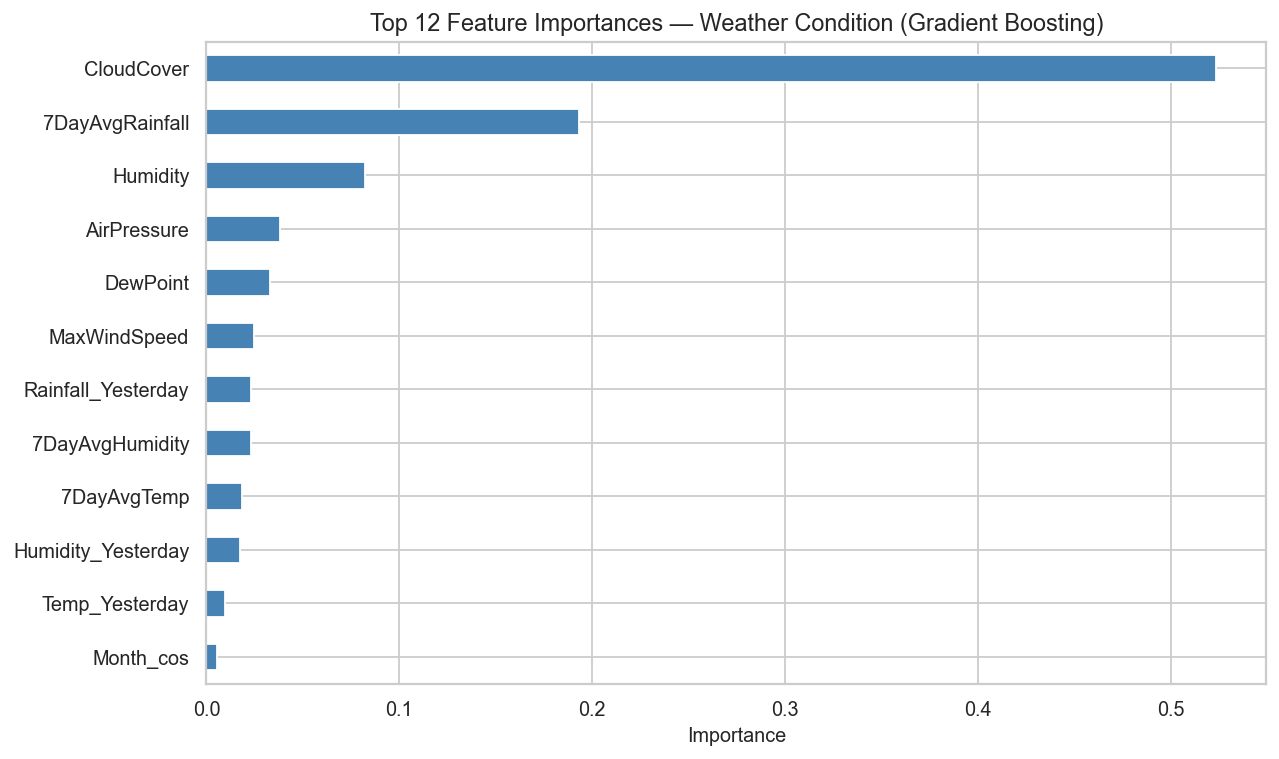

In [48]:
# Feature Importance — Weather Condition
feat_imp_m = pd.Series(gbc_mc.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp_m.head(12).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 12 Feature Importances — Weather Condition (Gradient Boosting)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('task3_weather_feature_importance.png', bbox_inches='tight')
plt.show()

<a id='7'></a>
## 7. Train vs Test Score — Master Summary Table

In [49]:
summary_rows = []

# Task 1
for name, model in [('Linear Regression', lr_reg), ('Decision Tree',  dt_reg), ('Random Forest', rf_reg), ('Gradient Boosting', gbr_reg), ('XGBoost',  xgb_reg)]:
    tr_p = model.predict(X_train_r)
    te_p = model.predict(X_test_r)
    summary_rows.append({
        'Task': '🌡️ Temperature',
        'Model': name,
        'Metric': 'MAE (°C) / R²',
        'Train Score': f"MAE={mean_absolute_error(y_train_r,tr_p):.3f}  R²={r2_score(y_train_r,tr_p):.4f}",
        'Test Score': f"MAE={mean_absolute_error(y_test_r,te_p):.3f}  R²={r2_score(y_test_r,te_p):.4f}",
        'Overfit?': 'Yes' if r2_score(y_train_r,tr_p)-r2_score(y_test_r,te_p) > 0.05 else 'No'
    })

# Task 2
for name, model in [('Logistic Regression', log_clf), ('Random Forest', rf_clf), ('Gradient Boosting', gbc_clf)]:
    tr_p = model.predict(X_train_c)
    te_p = model.predict(X_test_c)
    summary_rows.append({
        'Task': '🌧️ Rain',
        'Model': name,
        'Metric': 'Accuracy / F1',
        'Train Score': f"Acc={accuracy_score(y_train_c,tr_p):.4f}  F1={f1_score(y_train_c,tr_p):.4f}",
        'Test Score': f"Acc={accuracy_score(y_test_c,te_p):.4f}  F1={f1_score(y_test_c,te_p):.4f}",
        'Overfit?': 'Yes' if accuracy_score(y_train_c,tr_p)-accuracy_score(y_test_c,te_p) > 0.05 else 'No'
    })

# Task 3
for name, model in [('Logistic Regression', log_mc), ('Random Forest', rf_mc), ('Gradient Boosting', gbc_mc)]:
    tr_p = model.predict(X_train_m)
    te_p = model.predict(X_test_m)
    summary_rows.append({
        'Task': '⛅ Weather Cond.',
        'Model': name,
        'Metric': 'Accuracy / Weighted-F1',
        'Train Score': f"Acc={accuracy_score(y_train_m,tr_p):.4f}  F1={f1_score(y_train_m,tr_p,average='weighted'):.4f}",
        'Test Score': f"Acc={accuracy_score(y_test_m,te_p):.4f}  F1={f1_score(y_test_m,te_p,average='weighted'):.4f}",
        'Overfit?': 'Yes' if accuracy_score(y_train_m,tr_p)-accuracy_score(y_test_m,te_p) > 0.05 else 'No'
    })

summary_df = pd.DataFrame(summary_rows)
print('=== COMPLETE TRAIN vs TEST SCORE SUMMARY ===')
summary_df

=== COMPLETE TRAIN vs TEST SCORE SUMMARY ===


,Task,Model,Metric,Train Score,Test Score,Overfit?
0,🌡️ Temperature,Linear Regression,MAE (°C) / R²,MAE=0.659 R²=0.9835,MAE=0.616 R²=0.9756,No
1,🌡️ Temperature,Decision Tree,MAE (°C) / R²,MAE=0.343 R²=0.9949,MAE=1.374 R²=0.7629,Yes
2,🌡️ Temperature,Random Forest,MAE (°C) / R²,MAE=0.410 R²=0.9948,MAE=1.378 R²=0.7815,Yes
3,🌡️ Temperature,Gradient Boosting,MAE (°C) / R²,MAE=0.302 R²=0.9973,MAE=0.965 R²=0.9018,Yes
4,🌡️ Temperature,XGBoost,MAE (°C) / R²,MAE=0.137 R²=0.9994,MAE=0.974 R²=0.8930,Yes
5,🌧️ Rain,Logistic Regression,Accuracy / F1,Acc=0.8288 F1=0.7817,Acc=0.8311 F1=0.4219,No
6,🌧️ Rain,Random Forest,Accuracy / F1,Acc=1.0000 F1=1.0000,Acc=0.9247 F1=0.6118,Yes
7,🌧️ Rain,Gradient Boosting,Accuracy / F1,Acc=0.9983 F1=0.9977,Acc=0.9018 F1=0.5275,Yes
8,⛅ Weather Cond.,Logistic Regression,Accuracy / Weighted-F1,Acc=0.7871 F1=0.7897,Acc=0.8311 F1=0.8303,No
9,⛅ Weather Cond.,Random Forest,Accuracy / Weighted-F1,Acc=1.0000 F1=1.0000,Acc=0.8790 F1=0.8804,Yes


**📌 Interpretation Guide:**
- If `Train Score >> Test Score` → **Overfitting** (model memorized training data)
- If both scores are similar and low → **Underfitting** (model too simple)
- **Ideal:** Train ≈ Test, both high
- **Random Forest** tends to overfit here (Train=1.000, Test drops); **Gradient Boosting** generalizes better
- **Linear/Logistic Regression** shows least overfitting — good as a baseline

<a id='8'></a>
## 8. Inference — Predict for New Input

In [50]:
# Fill in any new day's readings
# City encoding: Islamabad=0, Karachi=1, Lahore=2, Multan=3, Peshawar=4, Quetta=5

month = 7   # July (peak summer)

new_sample = pd.DataFrame([{
    'Temp_Yesterday'    : 32.0,
    '7DayAvgTemp'       : 31.5,
    'Humidity'          : 75.0,
    'Humidity_Yesterday': 72.0,
    '7DayAvgHumidity'   : 70.0,
    'AirPressure'       : 1005.0,
    'DewPoint'          : 24.0,
    'CloudCover'        : 80.0,
    'MaxWindSpeed'      : 25.0,
    'Rainfall_Yesterday': 5.0,
    '7DayAvgRainfall'   : 8.5,
    'Visibility'        : 7,
    'Weekend'           : 1,
    'City_enc'          : 2,          # Lahore
    'Month_sin'         : np.sin(2*np.pi*month/12),
    'Month_cos'         : np.cos(2*np.pi*month/12),
    'Season_Winter'     : 0,
    'Season_Spring'     : 0,
    'Season_Summer'     : 1,
    'Season_Autumn'     : 0,
}])

# Make columns order same as training data
new_sample = new_sample[X_train_r.columns]

# Predictions
pred_temp = gbr_reg.predict(new_sample)[0]
pred_rain = gbc_clf.predict(new_sample)[0]
rain_prob  = gbc_clf.predict_proba(new_sample)[0]
pred_wc   = gbc_mc.predict(new_sample)[0]
wc_probs   = gbc_mc.predict_proba(new_sample)[0]

print('='*50)
print('📍 City: Lahore  |  Month: July  |  Season: Summer')
print('='*50)
print(f'🌡️  Predicted AvgTemp     : {pred_temp:.1f} °C')
print(f'🌧️  Rain Prediction       : {"Rain" if pred_rain==1 else "No Rain"}  '
      f'(No Rain: {rain_prob[0]*100:.1f}%  |  Rain: {rain_prob[1]*100:.1f}%)')
print(f'⛅  Weather Condition     : {le_wc.classes_[pred_wc]}  (confidence: {max(wc_probs)*100:.1f}%)')
print(f'    All probabilities: {", ".join([f"{le_wc.classes_[i]}: {p*100:.1f}%" for i,p in enumerate(wc_probs)])}')
print('='*50)

📍 City: Lahore  |  Month: July  |  Season: Summer
🌡️  Predicted AvgTemp     : 30.2 °C
🌧️  Rain Prediction       : Rain  (No Rain: 2.8%  |  Rain: 97.2%)
⛅  Weather Condition     : Rainy  (confidence: 98.0%)
    All probabilities: Cloudy: 1.8%, Moderate: 0.1%, Rainy: 98.0%, Sunny: 0.1%


In [53]:
### ==========================================
# USER INPUT WEATHER PREDICTION SYSTEM
# ==========================================

import pandas as pd
import numpy as np

print('='*60)
print('        WEATHER PREDICTION SYSTEM')
print('='*60)

# User Inputs
temp_yesterday = float(input('Enter Yesterday Temperature: '))
avg7_temp = float(input('Enter 7-Day Average Temperature: '))

humidity = float(input('Enter Humidity: '))
humidity_yesterday = float(input('Enter Yesterday Humidity: '))
avg7_humidity = float(input('Enter 7-Day Average Humidity: '))

air_pressure = float(input('Enter Air Pressure: '))
dew_point = float(input('Enter Dew Point: '))
cloud_cover = float(input('Enter Cloud Cover: '))

wind_speed = float(input('Enter Max Wind Speed: '))

rain_yesterday = float(input('Enter Yesterday Rainfall: '))
avg7_rain = float(input('Enter 7-Day Average Rainfall: '))

visibility = float(input('Enter Visibility: '))

weekend = int(input('Weekend? (1=Yes, 0=No): '))

# City Encoding
print('\nCity Encoding:')
print('Islamabad=0, Karachi=1, Lahore=2, Multan=3, Peshawar=4, Quetta=5')

city = int(input('Enter City Code: '))

# Month
month = int(input('Enter Month Number (1-12): '))

# Season Input
print('\nSeason Encoding:')
print('Winter=1, Spring=2, Summer=3, Autumn=4')

season = int(input('Enter Season Number: '))

# One-hot season encoding
season_winter = 1 if season == 1 else 0
season_spring = 1 if season == 2 else 0
season_summer = 1 if season == 3 else 0
season_autumn = 1 if season == 4 else 0

# Create DataFrame
new_sample = pd.DataFrame([{
    'Temp_Yesterday': temp_yesterday,
    '7DayAvgTemp': avg7_temp,
    'Humidity': humidity,
    'Humidity_Yesterday': humidity_yesterday,
    '7DayAvgHumidity': avg7_humidity,
    'AirPressure': air_pressure,
    'DewPoint': dew_point,
    'CloudCover': cloud_cover,
    'MaxWindSpeed': wind_speed,
    'Rainfall_Yesterday': rain_yesterday,
    '7DayAvgRainfall': avg7_rain,
    'Visibility': visibility,
    'Weekend': weekend,
    'City_enc': city,
    'Month_sin': np.sin(2*np.pi*month/12),
    'Month_cos': np.cos(2*np.pi*month/12),
    'Season_Winter': season_winter,
    'Season_Spring': season_spring,
    'Season_Summer': season_summer,
    'Season_Autumn': season_autumn
}])

# Match training feature order
new_sample = new_sample[X_train_r.columns]

# ==========================================
# PREDICTIONS
# ==========================================

pred_temp = gbr_reg.predict(new_sample)[0]

pred_rain = gbc_clf.predict(new_sample)[0]
rain_prob = gbc_clf.predict_proba(new_sample)[0]

pred_wc = gbc_mc.predict(new_sample)[0]
wc_probs = gbc_mc.predict_proba(new_sample)[0]

# ==========================================
# OUTPUT
# ==========================================

print('\n' + '='*60)
print('           PREDICTION RESULTS')
print('='*60)

print(f'🌡️ Predicted Avg Temperature : {pred_temp:.1f} °C')

print(f'🌧️ Rain Prediction : {"Rain" if pred_rain==1 else "No Rain"}')
print(f'   No Rain Probability : {rain_prob[0]*100:.1f}%')
print(f'   Rain Probability    : {rain_prob[1]*100:.1f}%')

print(f'\n⛅ Predicted Weather Condition : {le_wc.classes_[pred_wc]}')
print(f'Confidence : {max(wc_probs)*100:.1f}%')

print('\nAll Weather Probabilities:')
for i, p in enumerate(wc_probs):
    print(f'{le_wc.classes_[i]} : {p*100:.1f}%')

print('='*60)

        WEATHER PREDICTION SYSTEM


Enter Yesterday Temperature:  31
Enter 7-Day Average Temperature:  37
Enter Humidity:  51
Enter Yesterday Humidity:  47
Enter 7-Day Average Humidity:  52
Enter Air Pressure:  1003
Enter Dew Point:  15
Enter Cloud Cover:  10
Enter Max Wind Speed:  14
Enter Yesterday Rainfall:  1
Enter 7-Day Average Rainfall:  0.3
Enter Visibility:  1
Weekend? (1=Yes, 0=No):  1



City Encoding:
Islamabad=0, Karachi=1, Lahore=2, Multan=3, Peshawar=4, Quetta=5


Enter City Code:  0
Enter Month Number (1-12):  6



Season Encoding:
Winter=1, Spring=2, Summer=3, Autumn=4


Enter Season Number:  3



           PREDICTION RESULTS
🌡️ Predicted Avg Temperature : 30.9 °C
🌧️ Rain Prediction : No Rain
   No Rain Probability : 87.1%
   Rain Probability    : 12.9%

⛅ Predicted Weather Condition : Sunny
Confidence : 87.7%

All Weather Probabilities:
Cloudy : 0.0%
Moderate : 0.1%
Rainy : 12.1%
Sunny : 87.7%
